In [1]:
import torch
import math
from scipy.special import gamma
import matplotlib.pyplot as plt
import libra_py.dynamics.bohmian.compute as compute
#import libra_py.dynamics.tsh.plot as tsh_plot
import libra_py.units as units
import numpy as np
import matplotlib.gridspec as gridspec

%matplotlib inline

# 1. Misc stuff

In [2]:
def sech(x):
    return 1 / torch.cosh(x)
    
def Martens_model1(q, params):
    """
    q - Tensor(ntraj, ndof)
    """
    #params = {"Va": 0.00625, "Vb": 0.0106}
    return torch.sum( params["Va"] * sech(2.0*q[:, 0])**2 + 0.5 * params["Vb"] * q[:, 1]**2 , 0)

def Martens_model2(q, params):
    """
    q - Tensor(ntraj, ndof)

    Martens_model1 is just this one but with Vc = 0.0
    """
    #params = {"Va": 0.00625, "Vb": 0.0106}
    Va = params["Va"]
    Vb = params["Vb"]
    Vc = params["Vc"]
    return torch.sum( Va * sech(2.0*q[:, 0])**2 + 0.5 * Vb * (q[:, 1] + Vc * (q[:, 0]**2 - 1.0 ) )**2 , 0)


# Analytic Quantum Potential for a 1D Mixture of Gaussians

---

## Setup

Consider a probability density defined as a mixture of \(n\) identical-width 1D Gaussians:

$$
\rho(x)=f(x)=\frac{1}{n}\sum_{j=1}^{n} g_j(x),\qquad
g_j(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp\!\Big(-\frac{(x-x_j)^2}{2\sigma^2}\Big).
$$

We assume atomic units (\(\hbar=1\)).  
The quantum potential is

$$
U(x)=-\frac{1}{4m}\left(\frac{f''(x)}{f(x)}-\tfrac12\Big(\frac{f'(x)}{f(x)}\Big)^2\right).
$$

---

## Step 1 — define local weights

Define the normalized contributions of each Gaussian:

$$
w_j(x)\equiv\frac{g_j(x)}{f(x)}\qquad\text{so that}\qquad \sum_{j=1}^n w_j(x)=1.
$$

---

## Step 2 — derivatives of a Gaussian

Let

$$
a_j(x)\equiv x-x_j,\qquad s^2\equiv\sigma^2.
$$

Then

$$
\frac{g_j'(x)}{g_j(x)} = -\frac{a_j}{s^2},\qquad
\frac{g_j''(x)}{g_j(x)} = \frac{a_j^2}{s^4} - \frac{1}{s^2}.
$$

---

## Step 3 — express ratios in terms of weights

Since \(f = \sum_j g_j/n\), the constant cancels in ratios:

$$
\frac{f'}{f} = \sum_j w_j \frac{g_j'}{g_j},\qquad
\frac{f''}{f} = \sum_j w_j \frac{g_j''}{g_j}.
$$

Substituting Gaussian derivatives:

$$
\frac{f'}{f} = -\frac{1}{s^2}\sum_{j} w_j\,a_j,
$$

$$
\frac{f''}{f} = \sum_j w_j\left(\frac{a_j^2}{s^4} - \frac{1}{s^2}\right).
$$

---

## Step 4 — quantum potential in terms of \(A\) and \(B\)

Define

$$
A(x) \equiv \frac{f'}{f} = -\frac{1}{s^2}\sum_j w_j a_j,
\qquad
B(x) \equiv \frac{f''}{f} = \sum_j w_j\left(\frac{a_j^2}{s^4} - \frac{1}{s^2}\right).
$$

Then the quantum potential is

$$
U(x) = -\frac{1}{4m}\Big(B(x) - \tfrac12 A(x)^2\Big).
$$

---

## Final formula

$$
U(x) \;=\; -\frac{1}{4m}\left(
\sum_{j} w_j\!\left(\frac{(x-x_j)^2}{\sigma^4} - \frac{1}{\sigma^2}\right)
\;-\; \tfrac12\left(-\frac{1}{\sigma^2}\sum_{j} w_j (x-x_j)\right)^{\!2}
\right)
$$

where  
- \(a_j = x-x_j\),  
- \(s^2 = \sigma^2\),  
- \(w_j = \dfrac{g_j(x)}{\sum_k g_k(x)}\).

---

## Numerical stability

The weights \(w_j\) should be computed using the **log-sum-exp trick** to avoid underflow in the Gaussian tails:

```python
log_g = -0.5 * (a**2) / s2      # omit normalization constant
m = torch.max(log_g)
exp_shifted = torch.exp(log_g - m)
w = exp_shifted / exp_shifted.sum()


In [3]:
_SQRT_2PI = torch.sqrt(torch.tensor(2.0 * torch.pi))

def quantum_potential_gaussian_mixture(x, X, sigma, mass, eps=1e-16):
    """
    Analytic quantum potential for a 1D mixture of Gaussians (identical sigma).
    Args:
      x      : tensor scalar or shape (1,) - point where to evaluate (e.g. tensor([0.5]))
      X      : tensor shape (ntraj, 1) - centers x_j
      sigma  : tensor scalar or shape (1,) - width
      mass   : tensor scalar or shape (1,) - mass
      eps    : tiny floor to avoid /0 when absolutely necessary (default 1e-16)
    Returns:
      U      : tensor scalar (quantum potential at x)
    """
    
    # ensure shapes
    device = X.device
    x = x.view(-1)[0].to(device)            # scalar
    centers = X.view(-1).to(device)         # shape (ntraj,)
    s2 = (sigma.view(-1)[0]**2).to(device)

    # vector of (x - x_j)
    a = x - centers                          # shape (ntraj,)

    # compute log g_j up to additive constant
    # log_g_j = -0.5 * (a**2) / s2 - log(sigma*sqrt(2pi))
    # constant cancels in weights, so we can omit it for stability
    log_g = -0.5 * (a**2) / s2               # shape (ntraj,)

    # stable softmax to get weights w_j = g_j / sum g_k
    m = torch.max(log_g)
    exp_shifted = torch.exp(log_g - m)
    denom = exp_shifted.sum()
    # avoid zero denom (shouldn't happen unless all -inf)
    denom = denom  + eps
    w = exp_shifted / denom                  # shape (ntraj,)

    # compute A and B
    A = - (1.0 / s2) * (w * a).sum()                           # scalar
    B = (w * (a**2 / (s2**2) - 1.0 / s2)).sum()                # scalar

    # quantum potential (hbar=1)
    U = - (1.0 / (4.0 * mass.view(-1)[0])) * (B - 0.5 * (A**2))

    return U


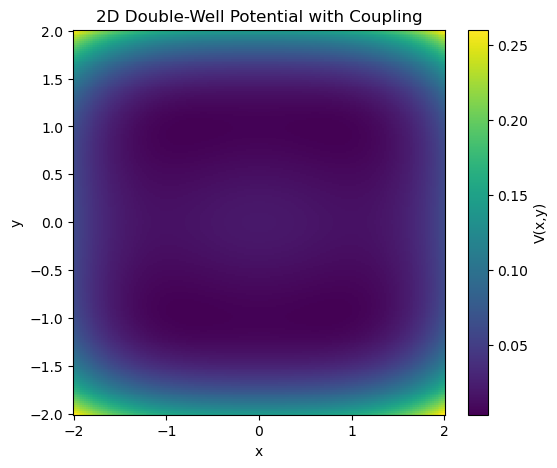

In [4]:
def double_well_2D(q, params):
    """
    2D double well with 4 minima and coupling term.
    
    q : Tensor (ntraj, 2)
    params : dict, e.g. {"a": 0.005, "b": 0.015, "c": 0.005}
    """
    a = params.get("a", 0.005)
    b = params.get("b", 0.015)
    c = params.get("c", 0.005)
    
    x = q[:, 0]
    y = q[:, 1]
    
    V = a * (x**2 - 1.0)**2 + b * (y**2 - 1.0)**2 + c * x**2 * y**2
    return V

# Parameters
params = {"a": 0.005, "b": 0.015, "c": 0.005}

# Grid for plotting
x = np.linspace(-2.0, 2.0, 200)
y = np.linspace(-2.0, 2.0, 200)
X, Y = np.meshgrid(x, y)

q = torch.tensor(np.stack([X.flatten(), Y.flatten()], axis=1), dtype=torch.float32)

# Compute potential on the grid
V = double_well_2D(q, params).detach().numpy().reshape(X.shape)

# Plot heatmap
plt.figure(figsize=(6, 5))
plt.pcolormesh(X, Y, V, shading="auto", cmap="viridis")
plt.colorbar(label="V(x,y)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Double-Well Potential with Coupling")
plt.show()


In [5]:
def quantum_potential_original_gen(q, Q, sigma, mass, TBF):
    """
    Args:
    * Q (Tensor(ntraj, ndof)) - coordinates of all trajectories
    * sigma (Tensor(ndof)) - width parameters for each trajectory
    * mass ( Tensor(ndof)) - masses of all DOFs, same for all trajectories
    * TBF (object) - basis function reference (`rho_gaussian` or `rho_lorentzian`)

    Returns:
    Tensor(1) - quantum potential summed over all trajectory points
    """

    ntraj, ndof = Q.shape[-2], Q.shape[-1]
    U = torch.zeros( (1,), requires_grad=True)
    f = TBF(q, Q, sigma);
    
    
    """
    [deriv1] = torch.autograd.grad(f, [q], create_graph=True, retain_graph=True);
    for i in range(ndof):
        [deriv2] = torch.autograd.grad(deriv1[i], [q], create_graph=True, retain_graph=True);
        
        print("x:", q.item(), "rho:", f.item(), "grad1:",deriv1, "grad2:", deriv2)
    """
    grad1 = torch.autograd.grad(f, q, create_graph=True)[0]  # shape (1,1)
    grad2 = []
    for i in range(ndof):
        g2 = torch.autograd.grad(grad1[0,i], q, create_graph=True)[0][0,i]
        #grad2.append(g2)
        
        #u = -(0.25/mass[i])*( deriv2[i]/f  - 0.5 * (deriv1[i]/f)**2 );
        u = -(0.25/mass[i])*( g2/f  - 0.5 * (grad1[0,i]/f)**2 );
        print("x:", q.item(), "rho:", f.item(), "grad1:", grad1[0, i], "grad2:", g2, "u:", u)
        U = U + u
    return U

In [6]:
def plot_rho_quant_pot(X, sigma, mass, TBF, title, xmin=-2.0, xmax = 2.0, do_analyt=0):
    x = torch.linspace(xmin, xmax, 100, requires_grad=True)
    rho, U, U_anal = [], [], []
    for _x in x:
        f = TBF(_x.view(1,1), X, sigma) # compute.rho_lorentzian
        u = compute.quantum_potential_original_gen(_x.view(1,1), X, sigma, mass, TBF) #compute.rho_lorentzian)
        u_an = quantum_potential_gaussian_mixture(_x.view(1,1), X, sigma, mass)
        rho.append(f.detach())
        U.append(u.detach())
        U_anal.append(u_an.detach())
    x = x.detach()
    
    #print(U)

    # Create 1 row, 2 columns of subplots
    fig, axs = plt.subplots(1, 2, figsize=(8, 4)) # sharex=True, sharey=True)
    
    axs[0].plot(x, rho, color="red", lw=3) 
    axs[0].set_ylabel('Probability Density', fontsize=18)
    axs[1].plot(x, U, color="red", lw=3, label = "Autodiff") 
    axs[1].set_ylabel('Quantum Potential', fontsize=18)
    if do_analyt==1:
        axs[1].plot(x, U_anal, color="blue", lw=1, label="Analytic") 
    
    sz = 14
    axs[0].tick_params(axis='x', labelsize=sz)  # change x-tick label size
    axs[0].tick_params(axis='y', labelsize=sz)  # change y-tick label size
    axs[1].tick_params(axis='x', labelsize=sz)  # change x-tick label size
    axs[1].tick_params(axis='y', labelsize=sz)  # change y-tick label size
     
    # Centered shared x-axis label
    fig.suptitle(title, fontsize=20)
    fig.supxlabel('Coordinate, a.u.', fontsize=18)
    plt.legend(fontsize=18)
    plt.tight_layout()
    plt.show()

In [7]:
X = torch.tensor([ [0.0], 
                   [1.0], 
                   [1.2] 
                 ])
sigma = torch.tensor([0.1])
mass = torch.tensor( [1.0] )

print(X.shape, X)
print(sigma.shape, sigma)
print(mass.shape, mass)

torch.Size([3, 1]) tensor([[0.0000],
        [1.0000],
        [1.2000]])
torch.Size([1]) tensor([0.1000])
torch.Size([1]) tensor([1.])


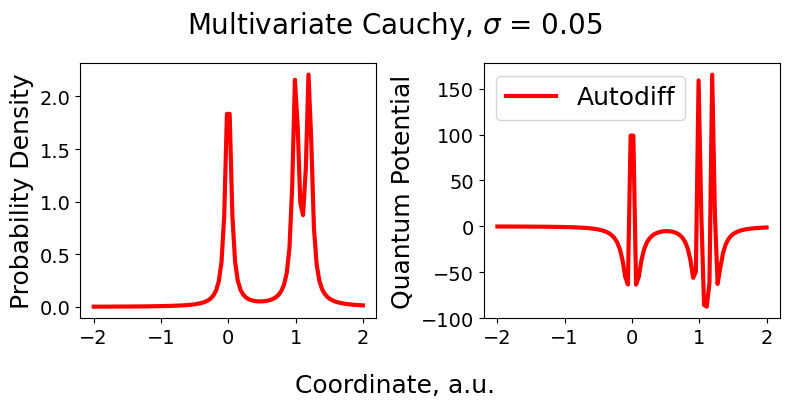

In [8]:
sigma = torch.tensor([0.05])
plot_rho_quant_pot(X, sigma, mass, compute.rho_mv_cauchy, "Multivariate Cauchy, $\sigma$ = 0.05")

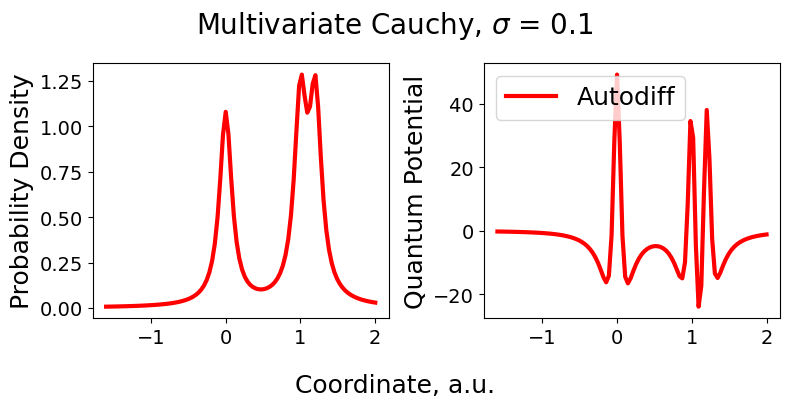

In [9]:
sigma = torch.tensor([0.1])
plot_rho_quant_pot(X, sigma, mass, compute.rho_mv_cauchy, "Multivariate Cauchy, $\sigma$ = 0.1",xmin = -1.6, xmax = 2.0)

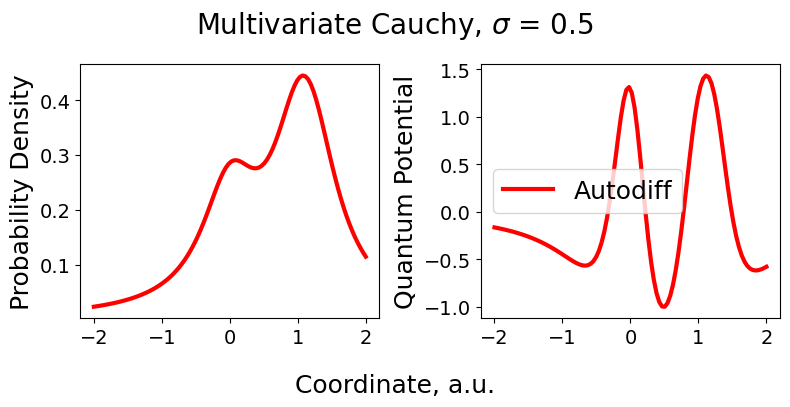

In [10]:
sigma = torch.tensor([0.5])
plot_rho_quant_pot(X, sigma, mass, compute.rho_mv_cauchy, "Multivariate Cauchy, $\sigma$ = 0.5")

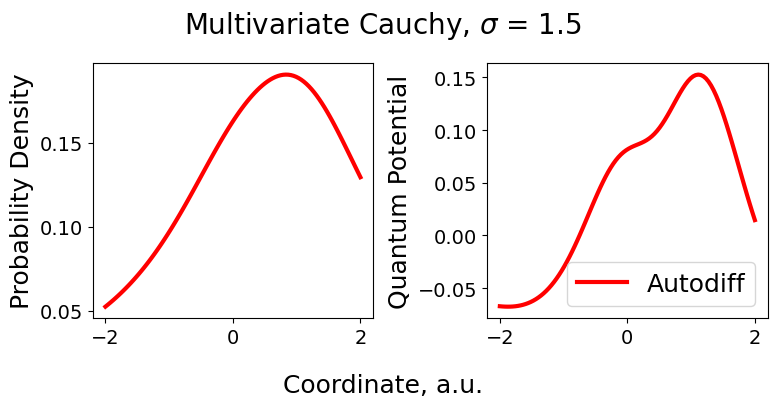

In [11]:
sigma = torch.tensor([1.5])
plot_rho_quant_pot(X, sigma, mass, compute.rho_mv_cauchy, "Multivariate Cauchy, $\sigma$ = 1.5")

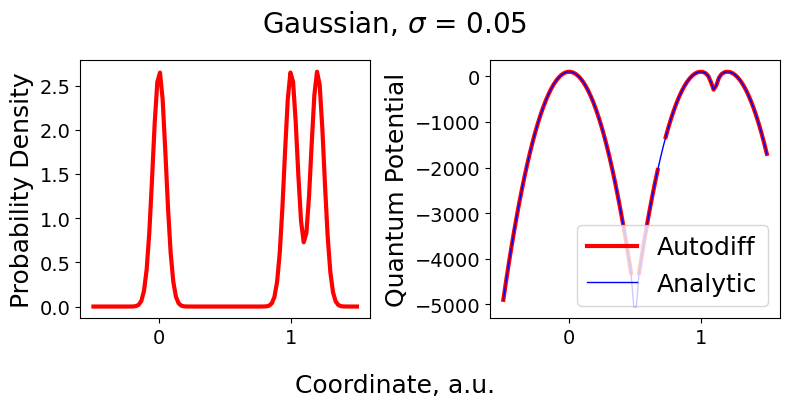

In [12]:
sigma = torch.tensor( [0.05] )
plot_rho_quant_pot(X, sigma, mass, compute.rho_gaussian, "Gaussian, $\sigma$ = 0.05", xmin = -0.5, xmax = 1.5, do_analyt=1)

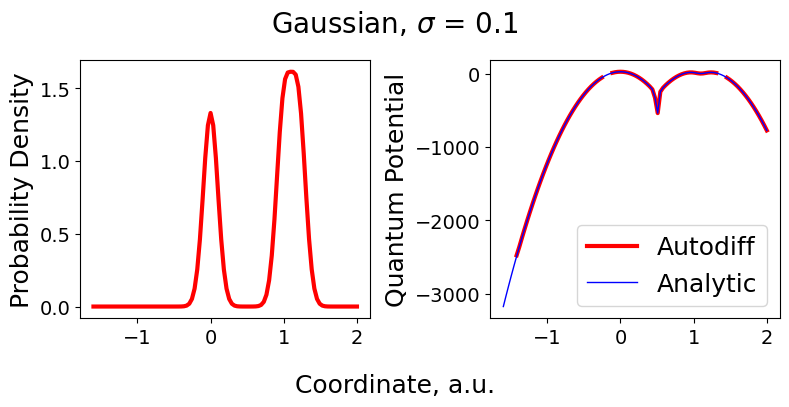

In [13]:
sigma = torch.tensor( [0.1] )
plot_rho_quant_pot(X, sigma, mass, compute.rho_gaussian, "Gaussian, $\sigma$ = 0.1", xmin = -1.6, xmax = 2.0, do_analyt=1)

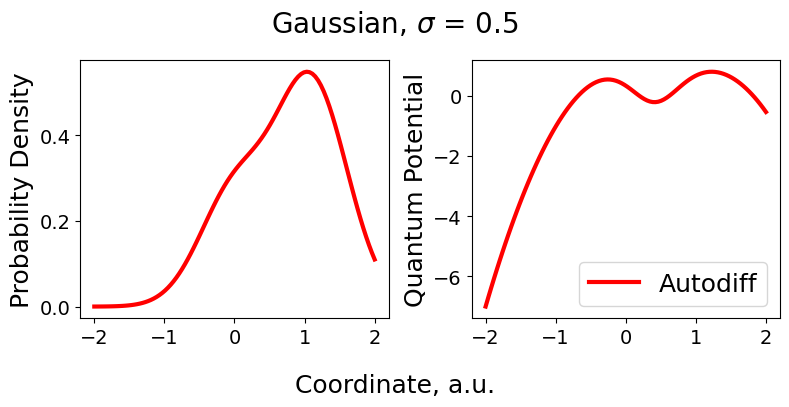

In [14]:
sigma = torch.tensor( [0.5] )
plot_rho_quant_pot(X, sigma, mass, compute.rho_gaussian, "Gaussian, $\sigma$ = 0.5")

# 2. Plotting transmission probabilities and energies

In [15]:
def plot_pop(plt, file_cl, file_bohm, file_qm, title, ntrajs, dts, kind_of_P, ymax=0.45, xmax=50, ncol=1):

    # Load the files
    #f_cl = torch.load(file_cl, weights_only=False)
    f_qm = torch.load(file_qm, weights_only=False)
    
    """
    f_bo1 = torch.load(F"{file_bohm}-1.pt", weights_only=False)  # sigma = 0.1, dt = 5
    f_bo2 = torch.load(F"{file_bohm}-2.pt", weights_only=False)  # sigma = 0.5, dt = 5 
    #f_bo3 = torch.load(F"{file_bohm}-3.pt", weights_only=False)  # sigma = 0.05, dt = 5 - poor energy conservation
    f_bo3b = torch.load(F"{file_bohm}-3b.pt", weights_only=False)# sigma = 0.05, dt = 2.5 - good energy conservation
    #f_bo_best = torch.load(F"{file_bohm}-best.pt")  # selecting the best parameters for all cases 
    kind_of_P - int: 0 - hard cutoff, 1 - oft cutoff
    """
    
    
    plt.rc('axes', titlesize=24)      # fontsize of the axes title
    plt.rc('axes', labelsize=24)      # fontsize of the x and y labels
    plt.rc('legend', fontsize=24)     # legend fontsize
    plt.rc('xtick', labelsize=24)    # fontsize of the tick labels
    plt.rc('ytick', labelsize=24)    # fontsize of the tick labels

    plt.rc('figure.subplot', left=0.2)
    plt.rc('figure.subplot', right=0.95)
    plt.rc('figure.subplot', bottom=0.13)
    plt.rc('figure.subplot', top=0.88)
    
    fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
    axs[0].set_ylabel('Transmission', fontsize=18)
    
    plt.xlim(0, xmax)
    plt.ylim(0, ymax)
    
    for ntraj in ntrajs:
        for dt in dts:
            f_bo = torch.load(F"{file_bohm}-ntraj{ntraj}-dt{dt}.pt", weights_only=False) 

            t, P = f_bo["t"], f_bo["P"][:, kind_of_P]
            #nsteps = len(P)
            #P = P - P[0] #torch.tensor( [P[0]]*nsteps )
            axs[0].plot(t[:]/units.fs2au, P, label=F"N = {ntraj}", linewidth=3) #, color="cyan")
            #print(P)
            f_cl = torch.load(F"{file_cl}-ntraj{ntraj}-dt{dt}.pt", weights_only=False)
            t, P = f_cl["t"], f_cl["P"][:, kind_of_P] #[:, kind_of_P]
            #P = P - P[0] #- torch.tensor( [P[0]]*nsteps )
            axs[1].plot(t[:]/units.fs2au, P, label=F"N = {ntraj}", linewidth=3) #, color="red")
    
    t, P = torch.tensor(f_qm["time"]), f_qm["population_right"]
    axs[0].plot(t[:]/units.fs2au, P, label="quantum", linewidth=5, ls="dotted", color="black")
    axs[1].plot(t[:]/units.fs2au, P, label="quantum", linewidth=5, ls="dotted", color="black")

    
    axs[0].set_title("Bohmian", fontsize=20)
    axs[1].set_title("Classical", fontsize=20)
    fig.suptitle(F"{title}", fontsize=20)
    fig.supxlabel('Time, fs', fontsize=18)
    axs[0].legend(fontsize=10, ncol=ncol)
    #axs[1].legend(fontsize=10)
    plt.tight_layout()
    plt.show()

In [16]:
def plot_energy(plt, file_cl, file_bohm, file_qm, title, ntrajs, dts,xmax=50,ncol=1):

    # Load the files
    #f_cl = torch.load(file_cl, weights_only=False)
    f_qm = torch.load(file_qm, weights_only=False)
    
    """
    f_bo1 = torch.load(F"{file_bohm}-1.pt", weights_only=False)  # sigma = 0.1, dt = 5
    f_bo2 = torch.load(F"{file_bohm}-2.pt", weights_only=False)  # sigma = 0.5, dt = 5 
    #f_bo3 = torch.load(F"{file_bohm}-3.pt", weights_only=False)  # sigma = 0.05, dt = 5 - poor energy conservation
    f_bo3b = torch.load(F"{file_bohm}-3b.pt", weights_only=False)# sigma = 0.05, dt = 2.5 - good energy conservation
    #f_bo_best = torch.load(F"{file_bohm}-best.pt")  # selecting the best parameters for all cases 
    """
    
    
    plt.rc('axes', titlesize=24)      # fontsize of the axes title
    plt.rc('axes', labelsize=24)      # fontsize of the x and y labels
    plt.rc('legend', fontsize=24)     # legend fontsize
    plt.rc('xtick', labelsize=24)    # fontsize of the tick labels
    plt.rc('ytick', labelsize=24)    # fontsize of the tick labels

    plt.rc('figure.subplot', left=0.2)
    plt.rc('figure.subplot', right=0.95)
    plt.rc('figure.subplot', bottom=0.13)
    plt.rc('figure.subplot', top=0.88)
    
    fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
    axs[0].set_ylabel('Energy, a.u.', fontsize=18)
    
    plt.xlim(0, xmax)
    #plt.ylim(0, 0.45)
    
    for ntraj in ntrajs:
        for dt in dts:
            f_bo = torch.load(F"{file_bohm}-ntraj{ntraj}-dt{dt}.pt", weights_only=False) 

            t, P = f_bo["t"], f_bo["E"][:,3].detach()
            axs[0].plot(t[:]/units.fs2au, P, label=F"N = {ntraj}", linewidth=3) #, color="cyan")
            
            f_cl = torch.load(F"{file_cl}-ntraj{ntraj}-dt{dt}.pt", weights_only=False)
            t, P = f_cl["t"], f_cl["E"][:,3].detach()
            axs[1].plot(t[:]/units.fs2au, P, label=F"N = {ntraj}", linewidth=3) #, color="red")
    
    t, P = torch.tensor(f_qm["time"]), f_qm["total_energy"]
    axs[0].plot(t[:]/units.fs2au, P, label="quantum", linewidth=5, ls="dotted", color="black")
    axs[1].plot(t[:]/units.fs2au, P, label="quantum", linewidth=5, ls="dotted", color="black")

    
    axs[0].set_title("Bohmian", fontsize=20)
    axs[1].set_title("Classical", fontsize=20)
    fig.suptitle(F"{title}", fontsize=20)
    fig.supxlabel('Time, fs', fontsize=18)
    axs[0].legend(fontsize=10, ncol=ncol)
    #axs[1].legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()

## Model I, Case 1

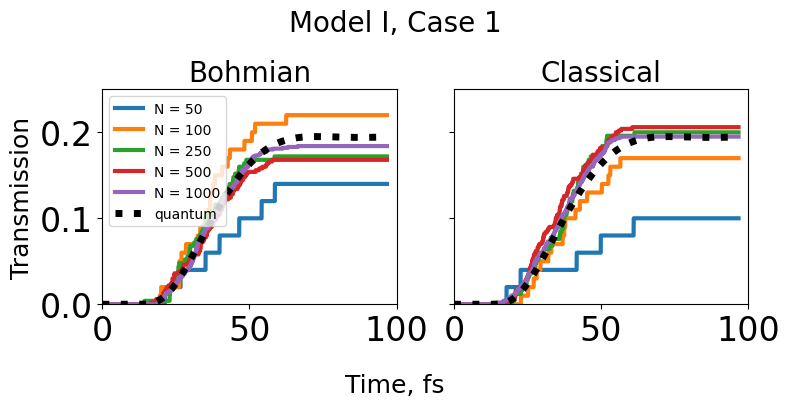

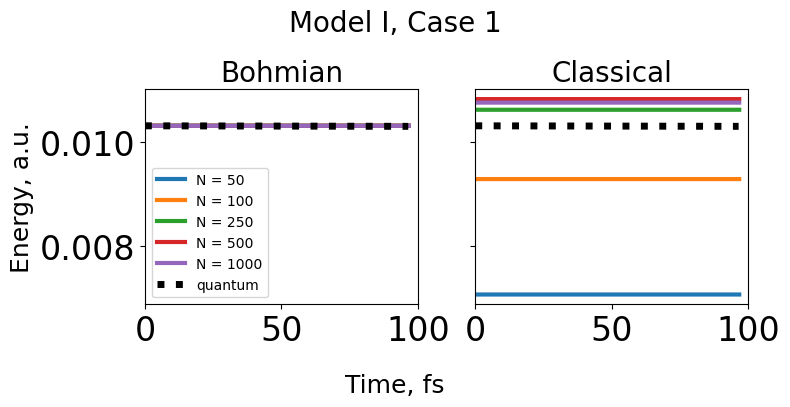

In [17]:
title = "Model I, Case 1"
plot_pop(plt, 
         "results/classical-MartensI-case1",
         "results/bohmian-mv_cauchy-MartensI-case1", "MartensI-case1-exact.pt", 
         title, [50, 100, 250, 500, 1000], [1.0], 0, ymax=0.25, xmax=100, ncol=1)
plot_energy(plt, 
            "results/classical-MartensI-case1",
            "results/bohmian-mv_cauchy-MartensI-case1", "MartensI-case1-exact.pt", 
         title, [50, 100, 250, 500, 1000], [1.0],xmax=100, ncol=1)

## Model I, Case 2

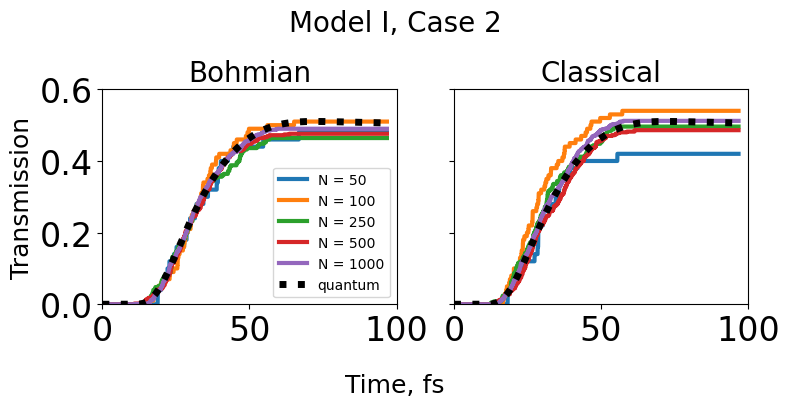

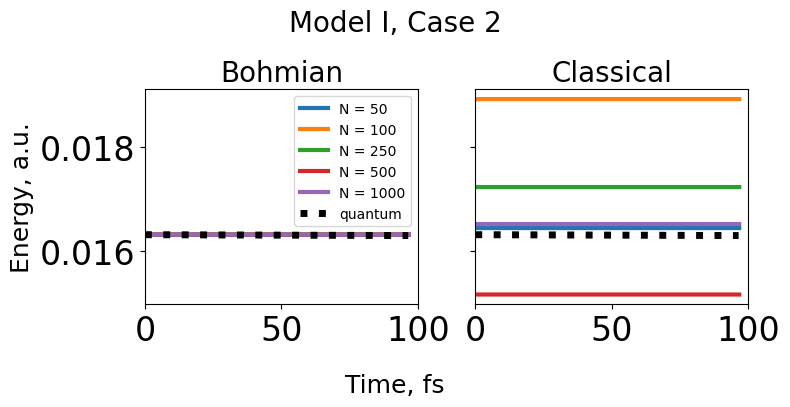

In [18]:
title = "Model I, Case 2"
plot_pop(plt, 
         "results/classical-MartensI-case2",
         "results/bohmian-mv_cauchy-MartensI-case2", "MartensI-case2-exact.pt", 
         title, [50, 100, 250, 500, 1000], [1.0], 0, 0.6, xmax=100, ncol=1)
plot_energy(plt,
            "results/classical-MartensI-case2",
            "results/bohmian-mv_cauchy-MartensI-case2", "MartensI-case2-exact.pt", 
         title, [50, 100, 250, 500, 1000], [1.0], xmax=100, ncol=1)

## Model II, Case 1

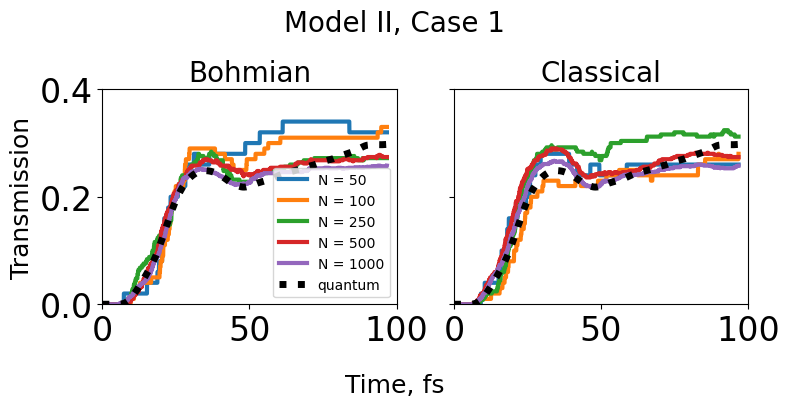

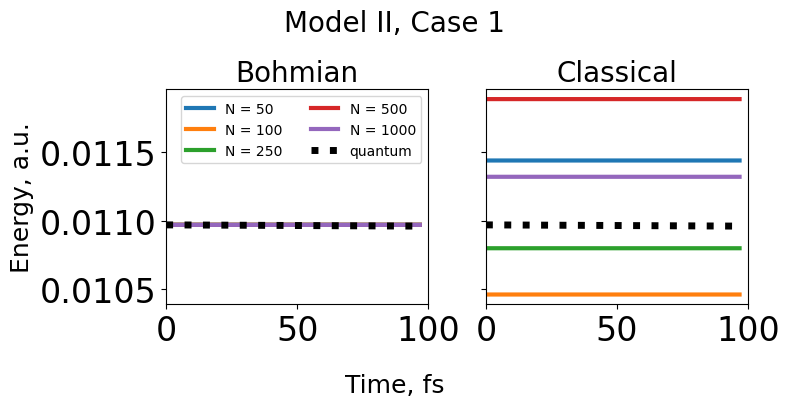

In [19]:
title = "Model II, Case 1"
plot_pop(plt, 
         "results/classical-MartensII-case1",
         "results/bohmian-mv_cauchy-MartensII-case1", "MartensII-case1-exact.pt", 
         title, [50, 100, 250, 500, 1000], [1.0], 0, 0.4,xmax=100, ncol=1)
plot_energy(plt,
            "results/classical-MartensII-case1",
            "results/bohmian-mv_cauchy-MartensII-case1", "MartensII-case1-exact.pt", 
         title, [50, 100, 250, 500, 1000], [1.0], xmax=100, ncol=2)

## Model I, Case 2

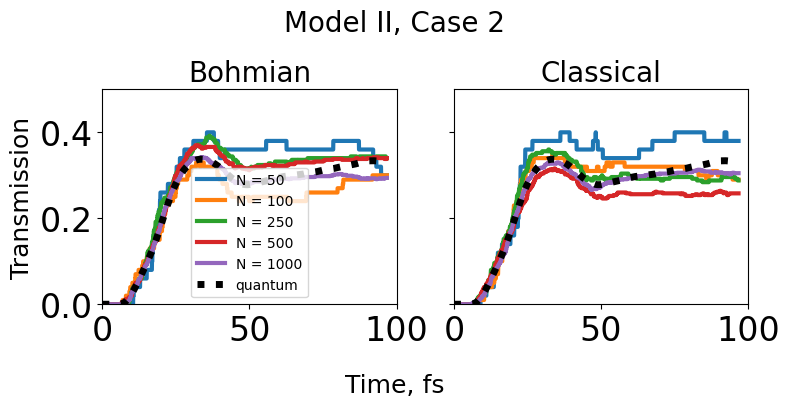

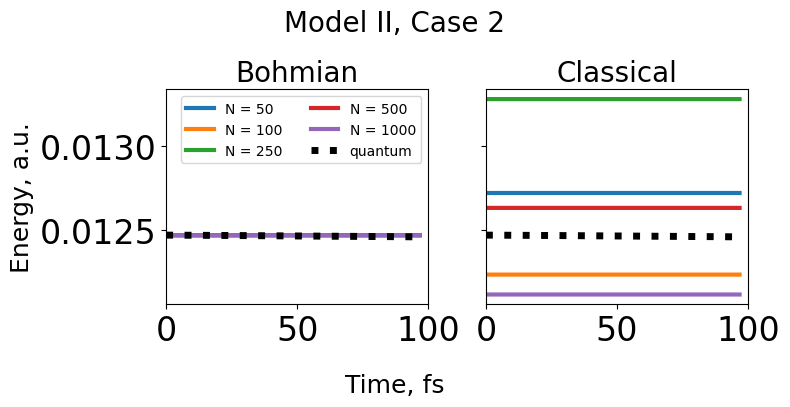

In [20]:
title = "Model II, Case 2"
plot_pop(plt, 
         "results/classical-MartensII-case2",
         "results/bohmian-mv_cauchy-MartensII-case2", "MartensII-case2-exact.pt", 
         title, [50, 100, 250, 500, 1000], [1.0], 0, 0.5, xmax=100, ncol=1)
plot_energy(plt,
            "results/classical-MartensII-case2",
            "results/bohmian-mv_cauchy-MartensII-case2", "MartensII-case2-exact.pt", 
         title, [50, 100, 250, 500, 1000], [1.0], xmax=100, ncol=2)

## Model III, Case 1

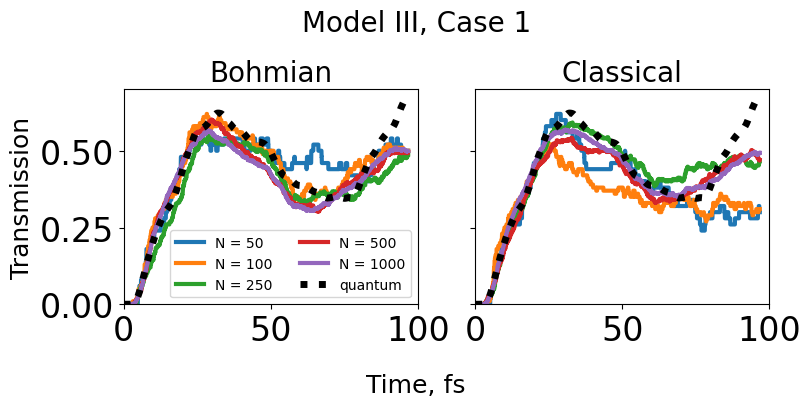

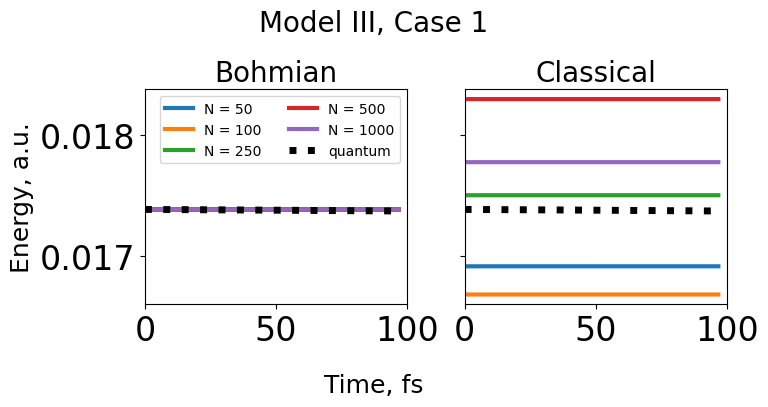

In [21]:
title = "Model III, Case 1"
plot_pop(plt, 
         "results/classical-Double_well_2D-case1",
         "results/bohmian-mv_cauchy-Double_well_2D-case1", "Double_well_2D-case1-exact.pt", 
         title, [50, 100, 250, 500, 1000], [1.0], 0, 0.7, 100, ncol=2)
plot_energy(plt,
            "results/classical-Double_well_2D-case1",
            "results/bohmian-mv_cauchy-Double_well_2D-case1", "Double_well_2D-case1-exact.pt", 
         title, [50, 100, 250, 500, 1000], [1.0], 100, ncol=2)

## Model III, Case 2

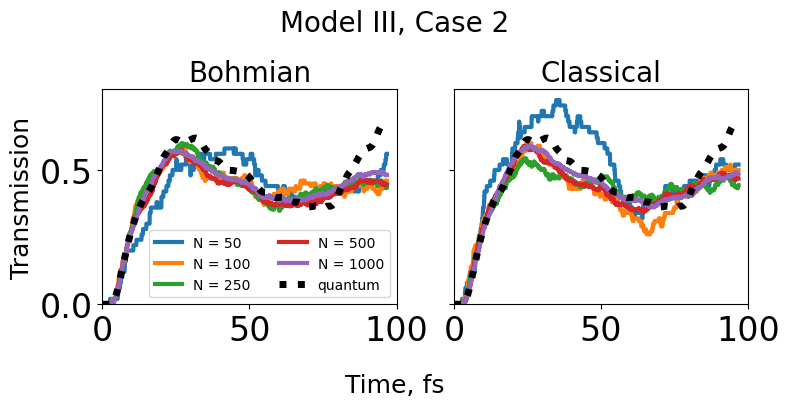

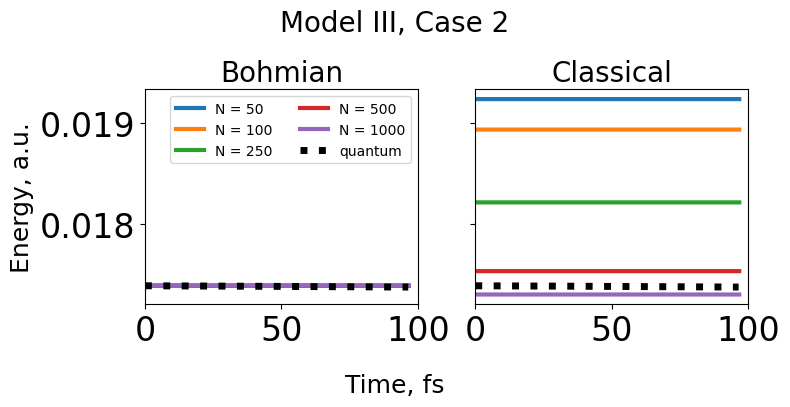

In [22]:
title = "Model III, Case 2"
plot_pop(plt, 
         "results/classical-Double_well_2D-case2",
         "results/bohmian-mv_cauchy-Double_well_2D-case2", "Double_well_2D-case2-exact.pt", 
         title, [50, 100, 250, 500, 1000], [1.0], 0, 0.8, 100, ncol=2)
plot_energy(plt,
            "results/classical-Double_well_2D-case2",
            "results/bohmian-mv_cauchy-Double_well_2D-case2", "Double_well_2D-case2-exact.pt", 
         title, [50, 100, 250, 500, 1000], [1.0], 100, ncol = 2)

In [23]:
def plot_all(plt, Ntraj, kind_of_P=0, ymax=0.45, xmax=50, ncol=1):
    
    plt.rc('axes', titlesize=24)      # fontsize of the axes title
    plt.rc('axes', labelsize=24)      # fontsize of the x and y labels
    plt.rc('legend', fontsize=24)     # legend fontsize
    plt.rc('xtick', labelsize=24)    # fontsize of the tick labels
    plt.rc('ytick', labelsize=24)    # fontsize of the tick labels

    plt.rc('figure.subplot', left=0.2)
    plt.rc('figure.subplot', right=0.95)
    plt.rc('figure.subplot', bottom=0.13)
    plt.rc('figure.subplot', top=0.88)
    
    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(3, 2, figure=fig)

    # --- Upper 2x2 grid with shared x-axis ---
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1], sharex=ax1)   # shares with ax1
    ax3 = fig.add_subplot(gs[1, 0], sharex=ax1)   # shares with ax1
    ax4 = fig.add_subplot(gs[1, 1], sharex=ax1)   # shares with ax1

    # --- Bottom row (independent x-axes) ---
    ax5 = fig.add_subplot(gs[2, 0])
    ax6 = fig.add_subplot(gs[2, 1])

        
    plt.xlim(0, xmax)
    plt.ylim(0, ymax)
 
    lw = 7

    axs = [ [ax1, ax2],
            [ax3, ax4],
            [ax5, ax6]
          ]
    files = [ [ "MartensI-case1", "MartensI-case2" ],
              [ "MartensII-case1", "MartensII-case2"],
              [ "Double_well_2D-case1", "Double_well_2D-case2" ]
            ]
    titles = [ [ "Model I, Case 1",  "Model I, Case 2"   ],
               [ "Model II, Case 1", "Model II, Case 2"  ],
               [ "Model III, Case 1","Model III, Case 2" ]
            ]
    
    for m in [0, 1, 2]:
        for cs in [0, 1]:
            
            file = files[m][cs]
            cl = torch.load(F"results/classical-{file}-ntraj{Ntraj}-dt1.0.pt", weights_only=False)
            bo = torch.load(F"results/bohmian-mv_cauchy-{file}-ntraj{Ntraj}-dt1.0.pt", weights_only=False)
            ex = torch.load(F"{file}-exact.pt", weights_only=False)

            t, P = torch.tensor(ex["time"]), ex["population_right"]
            if m==0 and cs==0:
                axs[m][cs].plot(cl["t"][:]/units.fs2au, cl["P"][:, kind_of_P], label="classical", linewidth=lw, color="red")
                axs[m][cs].plot(bo["t"][:]/units.fs2au, bo["P"][:, kind_of_P], label="Bohmian", linewidth=lw, color="green")
                axs[m][cs].plot(t[:]/units.fs2au, P, label="quantum", linewidth=lw, ls="dotted", color="black")
                axs[m][cs].legend(fontsize=20)
            else:
                axs[m][cs].plot(cl["t"][:]/units.fs2au, cl["P"][:, kind_of_P], linewidth=lw, color="red")
                axs[m][cs].plot(bo["t"][:]/units.fs2au, bo["P"][:, kind_of_P], linewidth=lw, color="green")
                axs[m][cs].plot(t[:]/units.fs2au, P, linewidth=lw, ls="dotted", color="black")                
            axs[m][cs].set_title(F"{titles[m][cs]}", fontsize=20)
        
    fig.supylabel('Transmission Probability', fontsize=22)
    fig.supxlabel('Time, fs', fontsize=22)
    #plt.legend(fontsize=22)
    plt.tight_layout()
    plt.show()

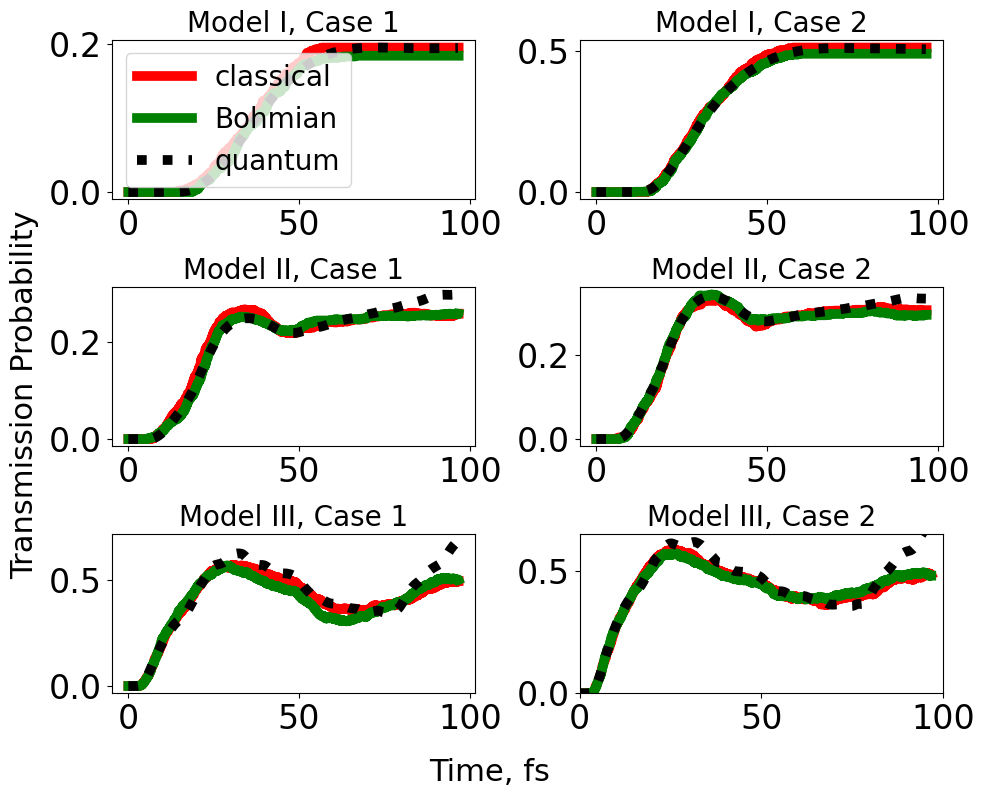

In [24]:
plot_all(plt, 1000, kind_of_P=0, ymax=0.65, xmax=100, ncol=1)

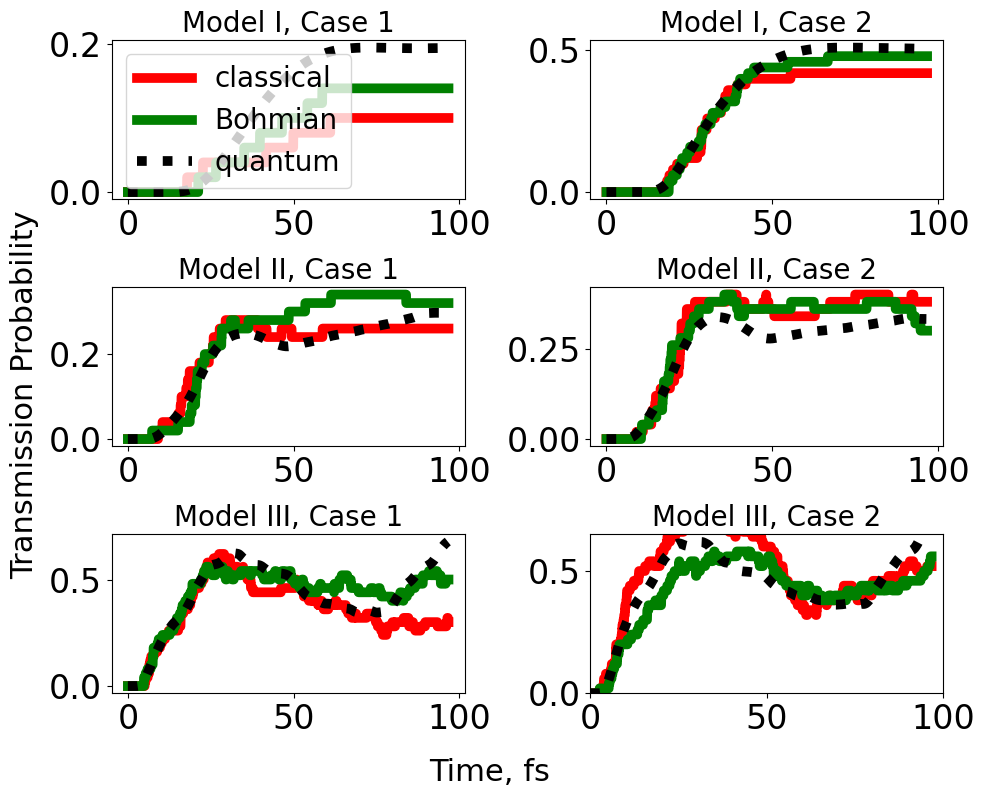

In [180]:
plot_all(plt, 50, kind_of_P=0, ymax=0.65, xmax=100, ncol=1)

# 3. Plotting dynamics

In [95]:
def plot_trajectory_dynamics(filename_quantum, filename, title, 
                             snapshots=[0, 100, 200, 290],
                             xlim=[-5.0, 5.0], ylim=[-2.0, 2.0],
                             nlevels=100
                            ):
    
    f = torch.load(filename_quantum, weights_only=False) #"MartensII-case1-exact.pt")
    c = torch.load(filename, weights_only=False) # trajectories 

    x = c["q_traj"][:,:,0].clone().detach()
    y = c["q_traj"][:,:,1].clone().detach()
    
    # Create 2 row, 2 columns of subplots
    fig, axs = plt.subplots(2, 2, figsize=(6, 6), sharex=True, sharey=True)
    
    for num, i in enumerate(snapshots):         
        n = f["save_every_n_steps"]
        dt = f["dt"]
        Q = f["Q"]
        V = f["V"]
        t = i * dt /units.fs2au
        psi = f["psi_all"][int(i/n)]
        rho = (torch.abs( psi ) )**2 
        a, b = int((num - num%2)/2), int(num % 2)
        axs[a, b].set_title(F"t = { round(t,0) } fs", fontsize=24)
        axs[a, b].set_xlim(xlim[0], xlim[1])
        axs[a, b].set_ylim(ylim[0], ylim[1])
    
        axs[a, b].scatter(x[i, :], y[i, :], color="red") #contourf(Q[0], Q[1], rho, levels=100, cmap="hot")
        axs[a, b].contour(Q[0], Q[1], V, levels = nlevels, colors='blue', linestyles='--')

    # Centered shared x-axis label
    fig.suptitle(title, fontsize=24)
    fig.supxlabel('X coordinate, a.u.', fontsize=20)
    fig.supylabel('Y coordinate, a.u.', fontsize=20)
    plt.tight_layout()
    plt.show()

In [90]:
#f = torch.load("MartensI-case1-exact.pt")
def plot_quantum_dynamics(filename, title,
                          snapshots=[0, 100, 200, 290],
                          xlim=[-5.0, 5.0], ylim=[-2.0, 2.0],
                          nlevels1=25, nlevels2=20):
    
    f = torch.load(filename, weights_only=False) #"MartensII-case1-exact.pt")
    # Create 2 row, 2 columns of subplots
    fig, axs = plt.subplots(2, 2, figsize=(6, 6), sharex=True, sharey=True)
    
    for num, i in enumerate(snapshots):     
        n = f["save_every_n_steps"]
        dt = f["dt"]
        Q = f["Q"]
        V = f["V"]
        t = i * dt /units.fs2au
        psi = f["psi_all"][int(i/n)]
        rho = (torch.abs( psi ) )**2 
        a, b = int((num - num%2)/2), int(num % 2)
        axs[a, b].set_title(F"t = { round(t,0) } fs", fontsize=24)
        axs[a, b].set_xlim(xlim[0], xlim[1])
        axs[a, b].set_ylim(ylim[0], ylim[1])        
        
        axs[a, b].contourf(Q[0], Q[1], rho, levels=nlevels1, cmap="coolwarm")
        axs[a,b].contour(Q[0], Q[1], V, levels=nlevels2, colors='white', linestyles='--')

    # Centered shared x-axis label
    fig.suptitle(title, fontsize=24)
    fig.supxlabel('X coordinate, a.u.', fontsize=20)
    fig.supylabel('Y coordinate, a.u.', fontsize=20)
    plt.tight_layout()
    plt.show()
# Good: PRGn, coolwarm, 

## Model I, Case 1

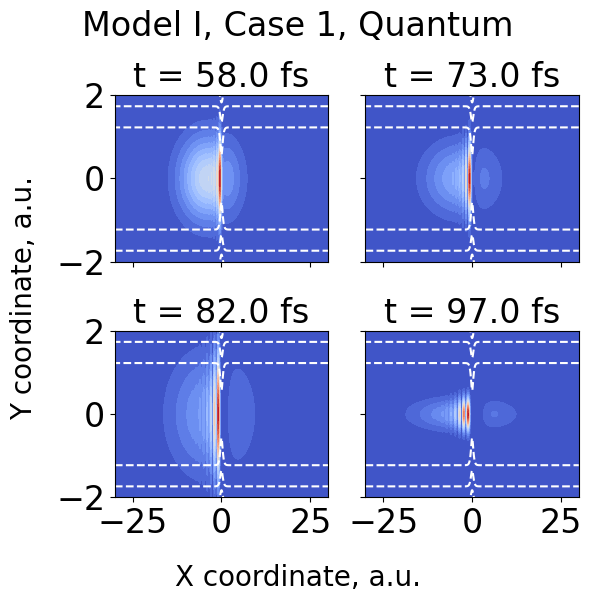

In [91]:
# snapshots=[0, 600, 1200, 1990],
plot_quantum_dynamics("MartensI-case1-exact.pt", 
                      "Model I, Case 1, Quantum",
                      snapshots=[2400, 3000, 3400, 3990],
                      xlim=[-30.0, 30.0], ylim=[-2.0, 2.0], nlevels1=25, nlevels2=20)

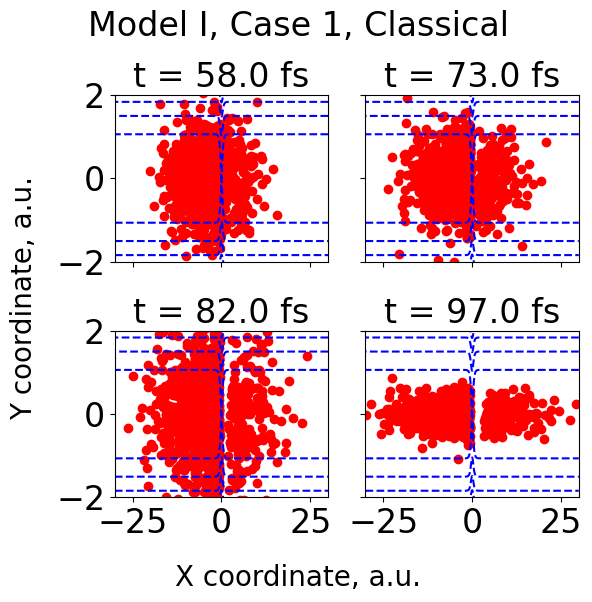

In [99]:
plot_trajectory_dynamics("MartensI-case1-exact.pt", 
                         "results/classical-MartensI-case1-ntraj1000-dt1.0.pt", "Model I, Case 1, Classical",
                         snapshots=[2400, 3000, 3400, 3990],
                         xlim=[-30.0, 30.0], ylim=[-2.0, 2.0], nlevels=25)

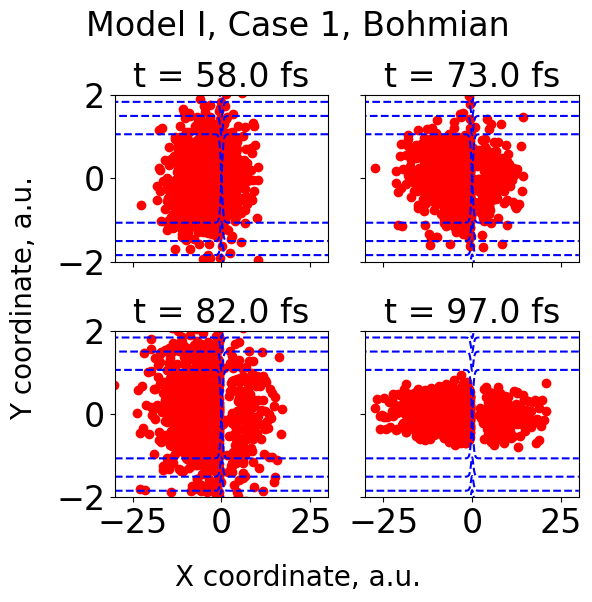

In [100]:
plot_trajectory_dynamics("MartensI-case1-exact.pt", 
                         "results/bohmian-mv_cauchy-MartensI-case1-ntraj1000-dt1.0.pt", "Model I, Case 1, Bohmian",
                         snapshots=[2400, 3000, 3400, 3990],
                         xlim=[-30.0, 30.0], ylim=[-2.0, 2.0], nlevels=25)

## Model I, Case 2

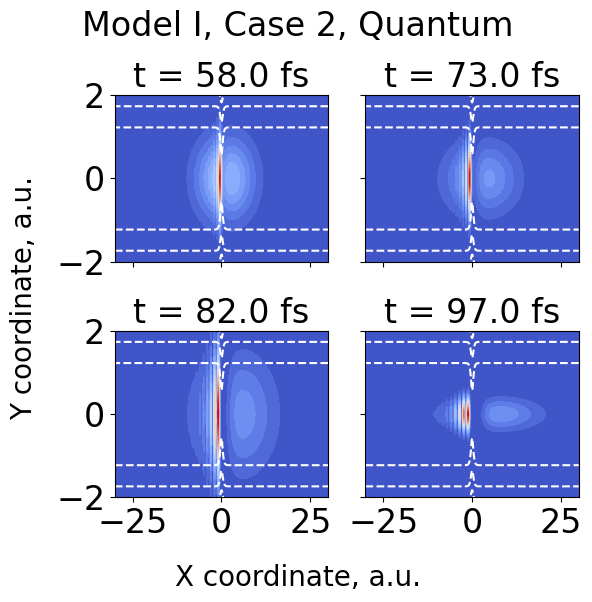

In [101]:
plot_quantum_dynamics("MartensI-case2-exact.pt", 
                      "Model I, Case 2, Quantum",
                      snapshots=[2400, 3000, 3400, 3990],
                      xlim=[-30.0, 30.0], ylim=[-2.0, 2.0], nlevels1=25, nlevels2=20)

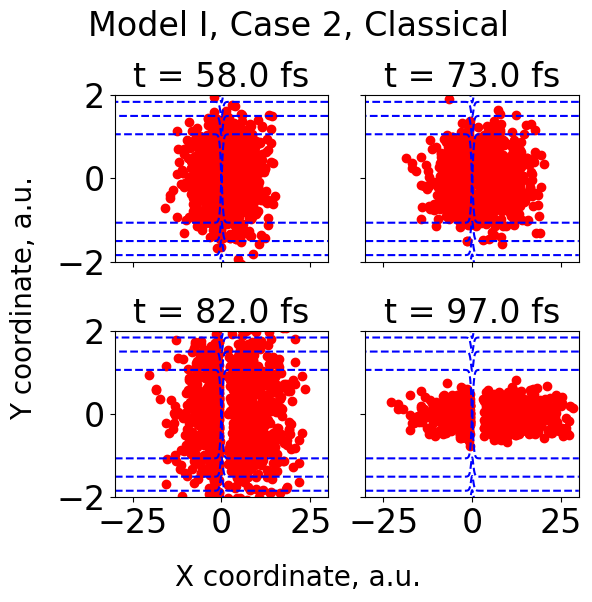

In [129]:
plot_trajectory_dynamics("MartensI-case2-exact.pt", 
                         "results/classical-MartensI-case2-ntraj1000-dt1.0.pt", "Model I, Case 2, Classical",
                         snapshots=[2400, 3000, 3400, 3990],
                         xlim=[-30.0, 30.0], ylim=[-2.0, 2.0], nlevels=25)

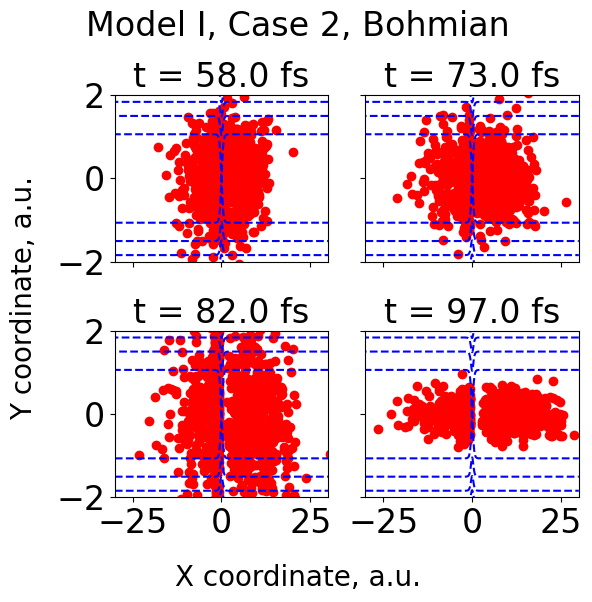

In [130]:
plot_trajectory_dynamics("MartensI-case2-exact.pt", 
                         "results/bohmian-mv_cauchy-MartensI-case2-ntraj1000-dt1.0.pt", "Model I, Case 2, Bohmian",
                         snapshots=[2400, 3000, 3400, 3990],
                         xlim=[-30.0, 30.0], ylim=[-2.0, 2.0], nlevels=25)

## Model II, Case 1

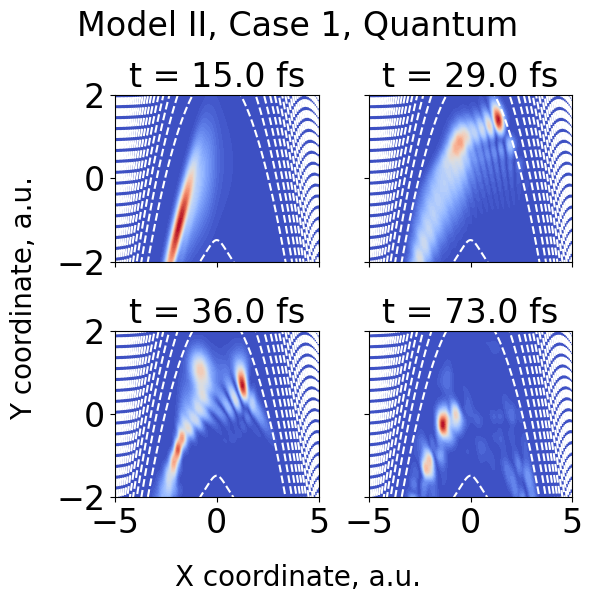

In [115]:
plot_quantum_dynamics("MartensII-case1-exact.pt", 
                      "Model II, Case 1, Quantum",
                      snapshots=[600, 1200, 1500, 3000],
                      xlim=[-5.0, 5.0], ylim=[-2.0, 2.0], nlevels1=50, nlevels2=50)

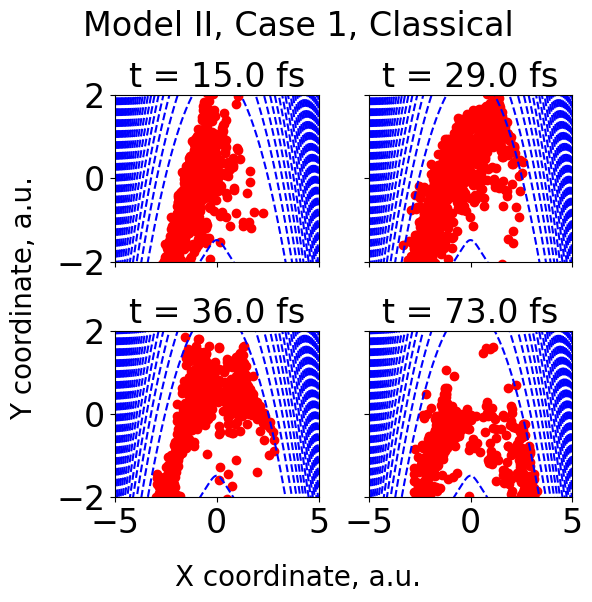

In [131]:
plot_trajectory_dynamics("MartensII-case1-exact.pt", 
                         "results/classical-MartensII-case1-ntraj1000-dt1.0.pt", "Model II, Case 1, Classical",
                         snapshots=[600, 1200, 1500, 3000],
                         xlim=[-5.0, 5.0], ylim=[-2.0, 2.0], nlevels=50)

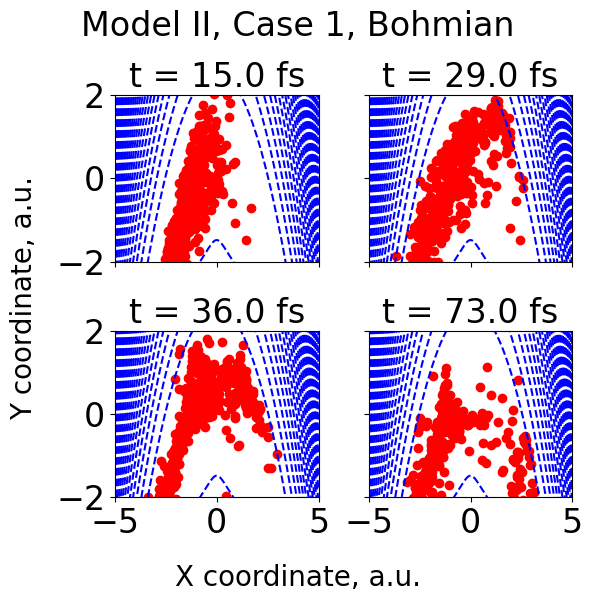

In [132]:
plot_trajectory_dynamics("MartensII-case1-exact.pt", 
                         "results/bohmian-mv_cauchy-MartensII-case1-ntraj500-dt1.0.pt", "Model II, Case 1, Bohmian",
                         snapshots=[600, 1200, 1500, 3000],
                         xlim=[-5.0, 5.0], ylim=[-2.0, 2.0], nlevels=50)

## Model II, Case 2

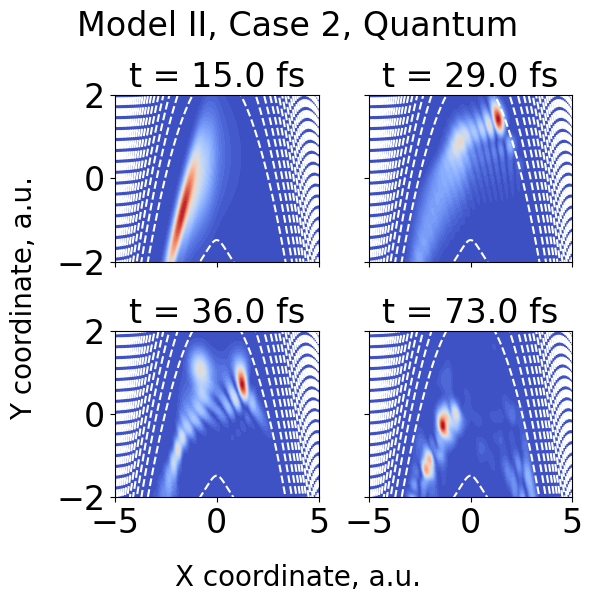

In [116]:
plot_quantum_dynamics("MartensII-case2-exact.pt", 
                      "Model II, Case 2, Quantum",
                      snapshots=[600, 1200, 1500, 3000],
                      xlim=[-5.0, 5.0], ylim=[-2.0, 2.0], nlevels1=50, nlevels2=50)

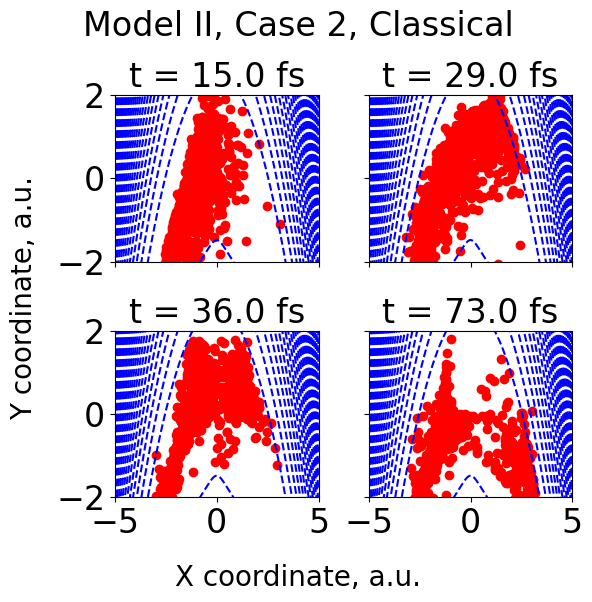

In [133]:
plot_trajectory_dynamics("MartensII-case2-exact.pt", 
                         "results/classical-MartensII-case2-ntraj1000-dt1.0.pt", "Model II, Case 2, Classical",
                         snapshots=[600, 1200, 1500, 3000],
                         xlim=[-5.0, 5.0], ylim=[-2.0, 2.0], nlevels=50)

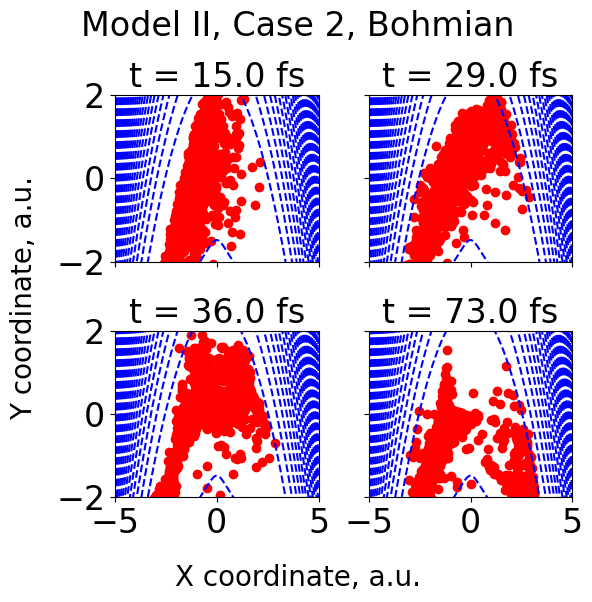

In [134]:
plot_trajectory_dynamics("MartensII-case2-exact.pt", 
                         "results/bohmian-mv_cauchy-MartensII-case2-ntraj1000-dt1.0.pt", "Model II, Case 2, Bohmian",
                         snapshots=[600, 1200, 1500, 3000],
                         xlim=[-5.0, 5.0], ylim=[-2.0, 2.0], nlevels=50)

## Model III, Case 1

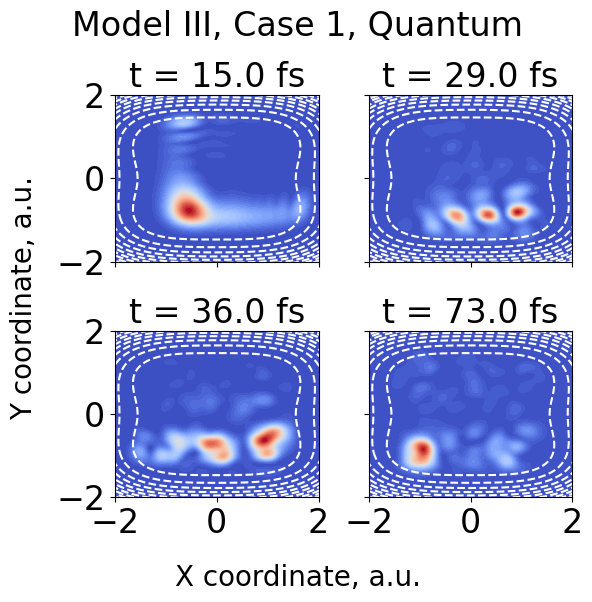

In [126]:
plot_quantum_dynamics("Double_well_2D-case1-exact.pt", 
                      "Model III, Case 1, Quantum",
                      snapshots=[600, 1200, 1500, 3000],
                      xlim=[-2.0, 2.0], ylim=[-2.0, 2.0], nlevels1=50, nlevels2=650)

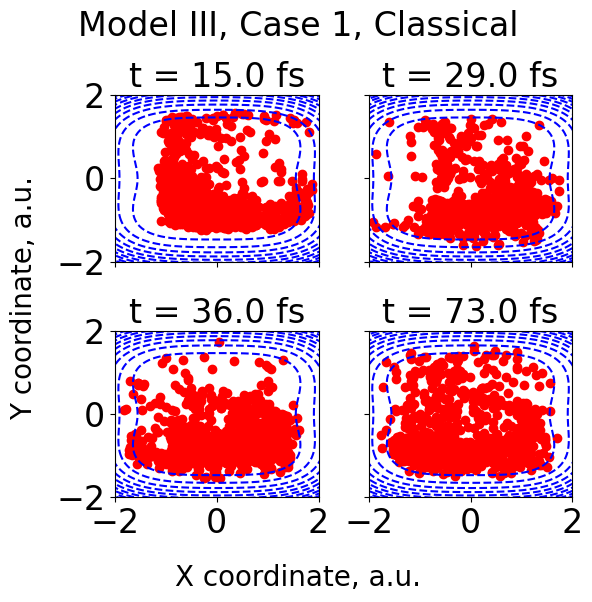

In [136]:
plot_trajectory_dynamics("Double_well_2D-case1-exact.pt", 
                         "results/classical-Double_well_2D-case1-ntraj1000-dt1.0.pt", "Model III, Case 1, Classical",
                         snapshots=[600, 1200, 1500, 3000],
                         xlim=[-2.0, 2.0], ylim=[-2.0, 2.0], nlevels=650)

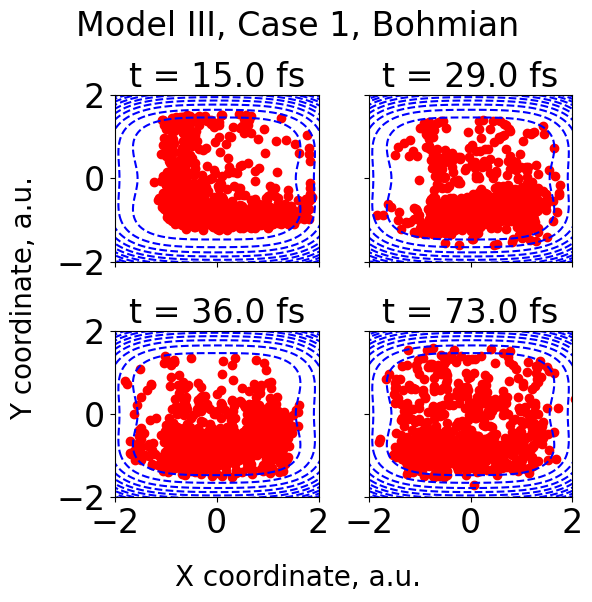

In [137]:
plot_trajectory_dynamics("Double_well_2D-case2-exact.pt", 
                         "results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj1000-dt1.0.pt", "Model III, Case 1, Bohmian",
                         snapshots=[600, 1200, 1500, 3000],
                         xlim=[-2.0, 2.0], ylim=[-2.0, 2.0], nlevels=650)

## Model III, Case 2

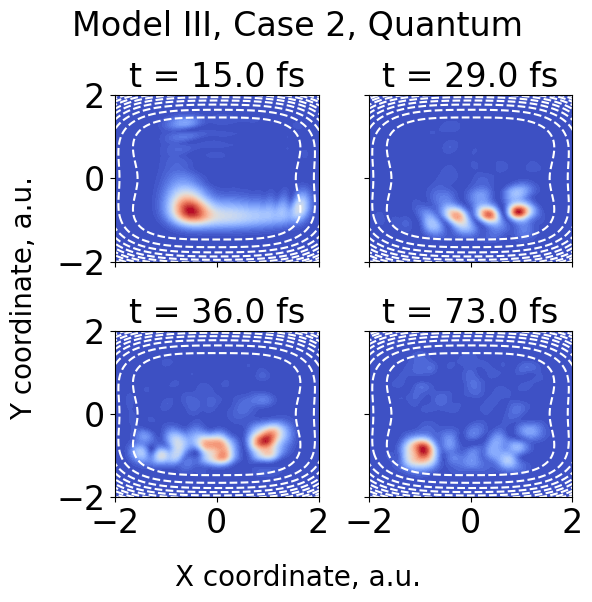

In [127]:
plot_quantum_dynamics("Double_well_2D-case2-exact.pt", 
                      "Model III, Case 2, Quantum",
                      snapshots=[600, 1200, 1500, 3000],
                      xlim=[-2.0, 2.0], ylim=[-2.0, 2.0], nlevels1=50, nlevels2=650)

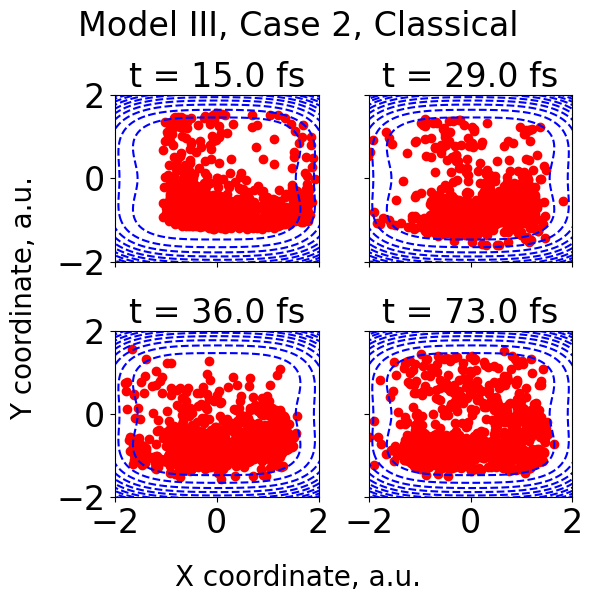

In [138]:
plot_trajectory_dynamics("Double_well_2D-case2-exact.pt", 
                         "results/classical-Double_well_2D-case2-ntraj1000-dt1.0.pt", "Model III, Case 2, Classical",
                         snapshots=[600, 1200, 1500, 3000],
                         xlim=[-2.0, 2.0], ylim=[-2.0, 2.0], nlevels=650)

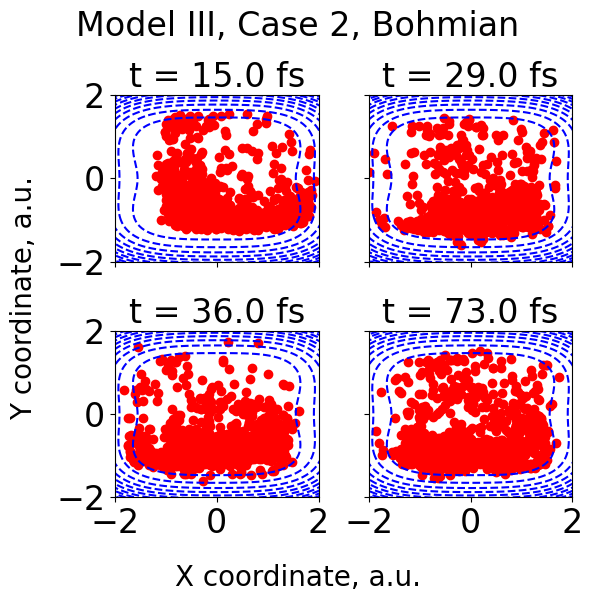

In [139]:
plot_trajectory_dynamics("Double_well_2D-case2-exact.pt", 
                         "results/bohmian-mv_cauchy-Double_well_2D-case2-ntraj1000-dt1.0.pt", "Model III, Case 2, Bohmian",
                         snapshots=[600, 1200, 1500, 3000],
                         xlim=[-2.0, 2.0], ylim=[-2.0, 2.0], nlevels=650)

# 4. Plotting density profiles and quantum potentials

In [185]:
def plot_rho_quant_pot_2D(filename_quantum, filename, _sigma, timestep, 
                          xmin=-10.0, xmax = 10.0, nptsx = 201,
                          ymin=-5.0, ymax = 5.0, nptsy=201):
    """
    # _sigma 
    # The standard deviation of the initial wavepacket 
    mass = 2000.0
    omega = 0.004
    sigma_q = np.sqrt(0.5/(mass*omega))
    print(sigma_q)
    # Use the Scott's rule for kernel bandwidth
    d = 2
    _sigma = sigma_q * _ntraj**(-1.0/(d+4)) # Scott's rule
    
    print(_sigma)
    """
    
    sigma = torch.tensor( [_sigma] )
    mass = torch.tensor( [2000.0, 2000.0] )

    qq = torch.load(filename_quantum, weights_only=False)    
    f = torch.load(filename, weights_only=False)    
    Q = f["q_traj"][timestep, :, :]
    
    x = torch.linspace(xmin, xmax, nptsx, requires_grad=True)
    y = torch.linspace(ymin, ymax, nptsy, requires_grad=True)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    X, Y = torch.meshgrid(x, y, indexing='ij')  # 'ij' indexing matches matrix notation    
    coords = torch.stack([X, Y], dim=-1) 
   
    rho, U = [], []
    # Then each entry coords[i, j] is a 2D vector [x, y]
        
    nx, ny = coords.shape[0], coords.shape[1]
    for _x in coords.reshape(-1, 2):
        ntraj, ndof = Q.shape[-2], Q.shape[-1]
        #f = rho_lorentzian(_x, Q, sigma)
        f = compute.rho_mv_cauchy(_x, Q, sigma)
        u = compute.quantum_potential_original_gen(_x, Q, sigma, mass, compute.rho_mv_cauchy) 
        rho.append(f.detach())
        U.append(u.detach())
    rho = torch.tensor(rho)
    rho = rho.reshape(nx, ny)
    
    U = torch.tensor(U)
    U = U.reshape(nx, ny)
            
    #rho = rho/norm
    #norm = (rho.sum() * dx * dy).detach().item()
    #rho = rho / norm
    rho_x = rho.sum(axis=1) * dy.detach().numpy()
    rho_y = rho.sum(axis=0) * dx.detach().numpy()

    print("Total norm Bohmian = ", rho.sum() * dx * dy)

    n = qq["save_every_n_steps"]
    dt = qq["dt"]
    dq = qq["dq"]
    qQ = qq["Q"]
    #V = qq["V"]
    t = timestep * dt /units.fs2au
    psi = qq["psi_all"][int(timestep/n)]
    qrho = (torch.abs( psi ) )**2 

    
    # Grid of quantum calculuations
    qx = torch.linspace(qq["q_min"][0], qq["q_max"][0], qq["grid_size"][0])
    qy = torch.linspace(qq["q_min"][1], qq["q_max"][1], qq["grid_size"][1])

    qrho_x = qrho.sum(axis=1) * (qy[1] - qy[0])
    qrho_y = qrho.sum(axis=0) * (qx[1] - qx[0])
    
    
    
    sz = 16
    # Create 1 row, 2 columns of subplots
    fig, axs = plt.subplots(2, 2, figsize=(6, 6)) # sharex=True, sharey=True)
    
    axs[0,0].plot(x.detach(), rho_x, color="red", label="Bohmian") 
    axs[0,0].plot(qx, qrho_x, color="blue", label="Quantum") 
    axs[0,0].set_ylabel(r"$\rho (x)$", fontsize=18)
    axs[0,0].legend(fontsize=18)
    axs[0,0].tick_params(axis='x', labelsize=sz)
    axs[0,0].tick_params(axis='y', labelsize=sz) 
    axs[0,0].set_xlim(xmin, xmax)  
    
    axs[0,1].plot(y.detach(), rho_y, color="red", label="Bohmian") 
    axs[0,1].plot(qy, qrho_y, color="blue", label="Quantum") 
    axs[0,1].set_ylabel(r"$\rho$ (y)", fontsize=18)
    axs[0,1].legend(fontsize=16)
    axs[0,1].tick_params(axis='x', labelsize=sz)
    axs[0,1].tick_params(axis='y', labelsize=sz) 
    axs[0,1].set_xlim(ymin, ymax)

    X = X.detach()
    Y = Y.detach()
    axs[1,0].contourf(X, Y, rho, levels=100, cmap="hot")
    axs[1,0].plot([], [], color="none", label="Density")
    axs[1,0].legend(fontsize=14)
    axs[1,0].set_ylabel('Coordinate, a.u.', fontsize=18)
    axs[1,0].tick_params(axis='x', labelsize=sz)
    axs[1,0].tick_params(axis='y', labelsize=sz) 
    axs[1,0].set_xlim(xmin, xmax)
    axs[1,0].set_ylim(ymin, ymax)

    axs[1,1].contour(X, Y, U, levels=100, cmap='hot')
    axs[1,1].plot([], [], color="none", label="Quantum Potential")
    axs[1,1].legend(fontsize=14)
    axs[1,1].tick_params(axis='x', labelsize=sz)
    axs[1,1].tick_params(axis='y', labelsize=sz) 
    axs[1,1].set_xlim(xmin, xmax)
    axs[1,1].set_ylim(ymin, ymax)
    
    # Centered shared x-axis label
    title = F"$\sigma$ = {_sigma:.3f} a.u. t = { round(t,0) } fs"
    fig.suptitle(title, fontsize=20)
    fig.supxlabel('Coordinate, a.u.', fontsize=18)
    #fig.supylabel('Coordinate, a.u.', fontsize=18)
    plt.tight_layout()
    plt.show()
    
    return rho_x, rho_y

## Model I

### N = 50

[2400, 3000, 3400, 3990]

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function Martens_model2 at 0x7a8e76660280>, 'ham_params': {'Va': 0.00625, 'Vb': 0.0106, 'Vc': 0.0}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(0.5920859200172514), 'prefix': 'results/bohmian-mv_cauchy-MartensI-case1-ntraj50-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.8709, dtype=torch.float64, grad_fn=<MulBackward0>)


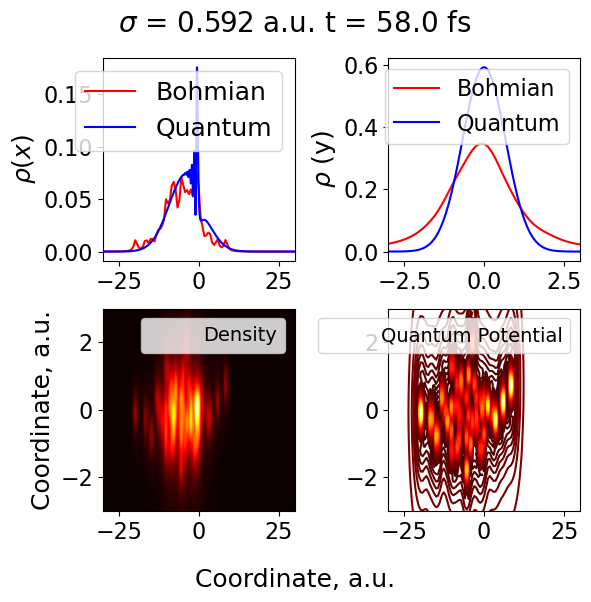

In [187]:
p = torch.load("results/bohmian-mv_cauchy-MartensI-case1-ntraj50-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("MartensI-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-MartensI-case1-ntraj50-dt1.0.pt", 
                      sigma, 2400,
                      -30.0, 30.0, 101, 
                      -3.0, 3.0, 51)

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function Martens_model2 at 0x7a8e76660280>, 'ham_params': {'Va': 0.00625, 'Vb': 0.0106, 'Vc': 0.0}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(0.5920859200172514), 'prefix': 'results/bohmian-mv_cauchy-MartensI-case1-ntraj50-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.8730, dtype=torch.float64, grad_fn=<MulBackward0>)


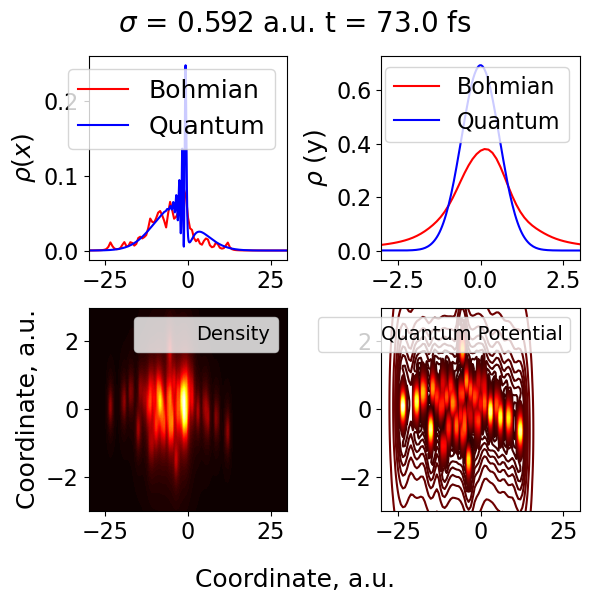

In [188]:
p = torch.load("results/bohmian-mv_cauchy-MartensI-case1-ntraj50-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("MartensI-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-MartensI-case1-ntraj50-dt1.0.pt", 
                      sigma, 3000,
                      -30.0, 30.0, 101, 
                      -3.0, 3.0, 51)

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function Martens_model2 at 0x7a8e76660280>, 'ham_params': {'Va': 0.00625, 'Vb': 0.0106, 'Vc': 0.0}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(0.5920859200172514), 'prefix': 'results/bohmian-mv_cauchy-MartensI-case1-ntraj50-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.8598, dtype=torch.float64, grad_fn=<MulBackward0>)


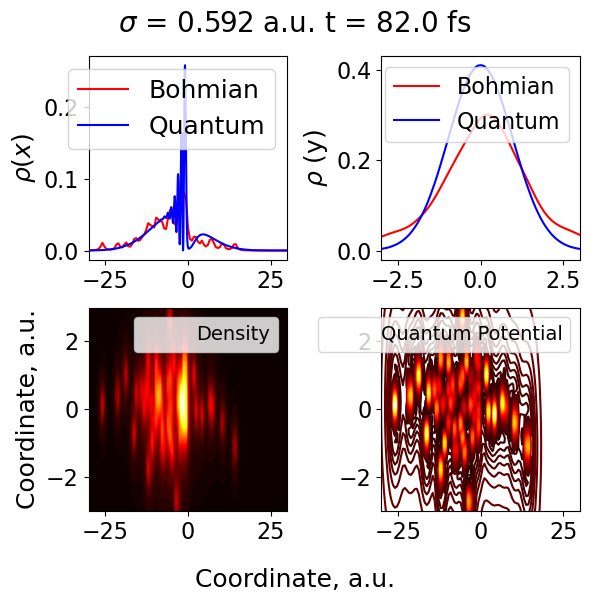

In [189]:
p = torch.load("results/bohmian-mv_cauchy-MartensI-case1-ntraj50-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("MartensI-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-MartensI-case1-ntraj50-dt1.0.pt", 
                      sigma, 3400,
                      -30.0, 30.0, 101, 
                      -3.0, 3.0, 51)

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function Martens_model2 at 0x7a8e76660280>, 'ham_params': {'Va': 0.00625, 'Vb': 0.0106, 'Vc': 0.0}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(0.5920859200172514), 'prefix': 'results/bohmian-mv_cauchy-MartensI-case1-ntraj50-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.8736, dtype=torch.float64, grad_fn=<MulBackward0>)


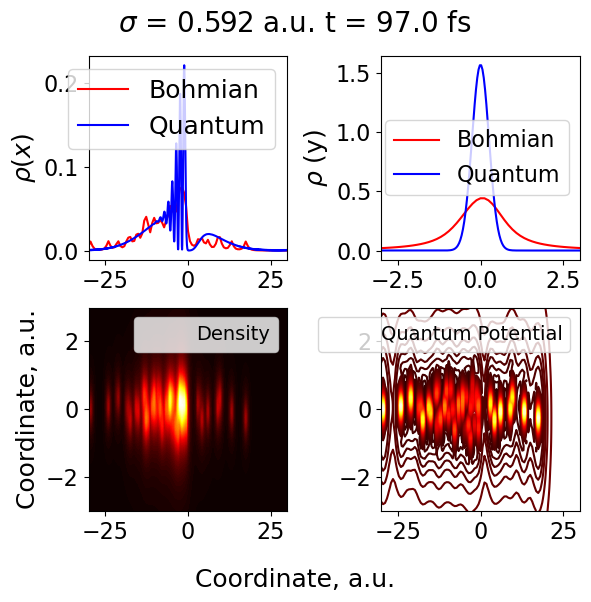

In [190]:
p = torch.load("results/bohmian-mv_cauchy-MartensI-case1-ntraj50-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("MartensI-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-MartensI-case1-ntraj50-dt1.0.pt", 
                      sigma, 3990,
                      -30.0, 30.0, 101, 
                      -3.0, 3.0, 51)

### N = 1000

[2400, 3000, 3400, 3990]

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function Martens_model2 at 0x7a8e76660280>, 'ham_params': {'Va': 0.00625, 'Vb': 0.0106, 'Vc': 0.0}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(1.0645239832188742), 'prefix': 'results/bohmian-mv_cauchy-MartensI-case1-ntraj1000-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.7751, dtype=torch.float64, grad_fn=<MulBackward0>)


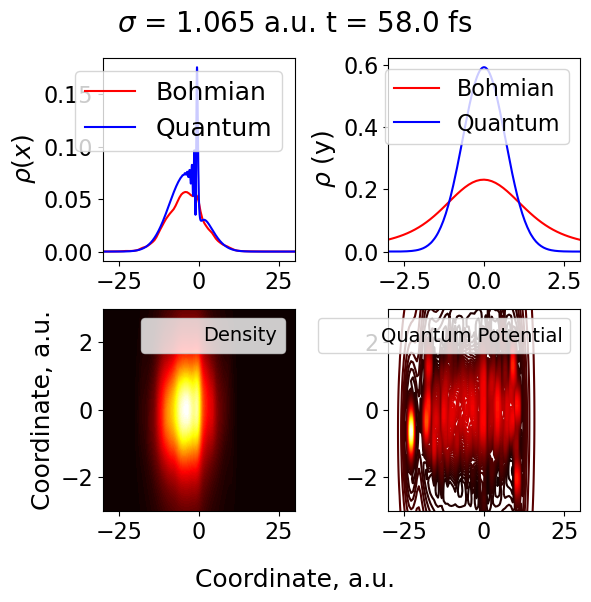

In [191]:
p = torch.load("results/bohmian-mv_cauchy-MartensI-case1-ntraj1000-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("MartensI-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-MartensI-case1-ntraj1000-dt1.0.pt", 
                      sigma, 2400,
                      -30.0, 30.0, 101, 
                      -3.0, 3.0, 51)

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function Martens_model2 at 0x7a8e76660280>, 'ham_params': {'Va': 0.00625, 'Vb': 0.0106, 'Vc': 0.0}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(1.0645239832188742), 'prefix': 'results/bohmian-mv_cauchy-MartensI-case1-ntraj1000-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.7796, dtype=torch.float64, grad_fn=<MulBackward0>)


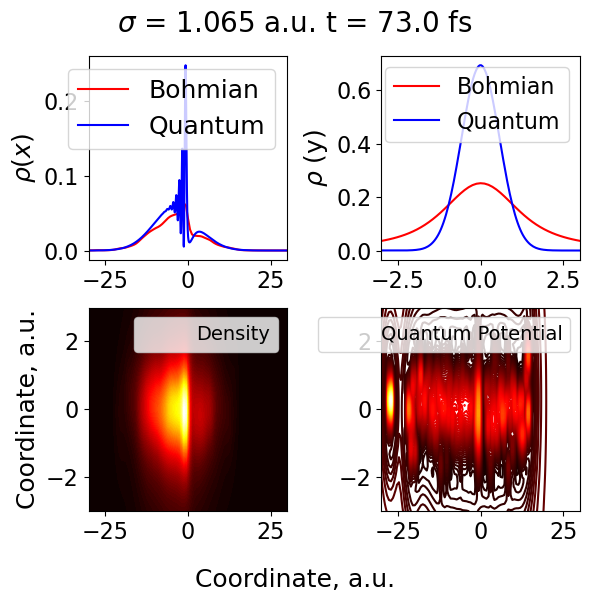

In [192]:
p = torch.load("results/bohmian-mv_cauchy-MartensI-case1-ntraj1000-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("MartensI-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-MartensI-case1-ntraj1000-dt1.0.pt", 
                      sigma, 3000,
                      -30.0, 30.0, 101, 
                      -3.0, 3.0, 51)

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function Martens_model2 at 0x7a8e76660280>, 'ham_params': {'Va': 0.00625, 'Vb': 0.0106, 'Vc': 0.0}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(1.0645239832188742), 'prefix': 'results/bohmian-mv_cauchy-MartensI-case1-ntraj1000-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.7623, dtype=torch.float64, grad_fn=<MulBackward0>)


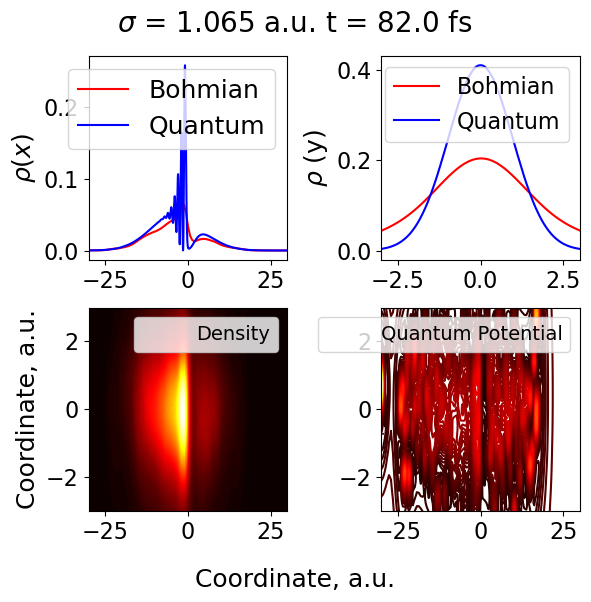

In [193]:
p = torch.load("results/bohmian-mv_cauchy-MartensI-case1-ntraj1000-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("MartensI-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-MartensI-case1-ntraj1000-dt1.0.pt", 
                      sigma, 3400,
                      -30.0, 30.0, 101, 
                      -3.0, 3.0, 51)

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function Martens_model2 at 0x7a8e76660280>, 'ham_params': {'Va': 0.00625, 'Vb': 0.0106, 'Vc': 0.0}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(1.0645239832188742), 'prefix': 'results/bohmian-mv_cauchy-MartensI-case1-ntraj1000-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.7825, dtype=torch.float64, grad_fn=<MulBackward0>)


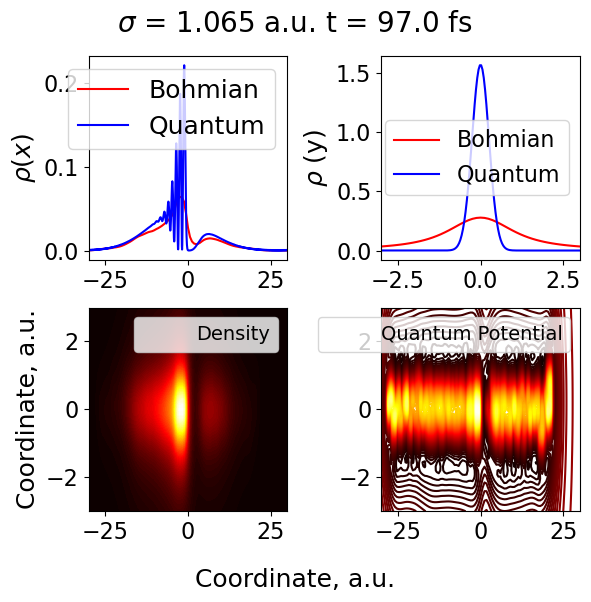

In [194]:
p = torch.load("results/bohmian-mv_cauchy-MartensI-case1-ntraj1000-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("MartensI-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-MartensI-case1-ntraj1000-dt1.0.pt", 
                      sigma, 3990,
                      -30.0, 30.0, 101, 
                      -3.0, 3.0, 51)

## Model II

[600, 1200, 1500, 3000]

### N = 50

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function Martens_model2 at 0x7a8e76660280>, 'ham_params': {'Va': 0.00625, 'Vb': 0.0106, 'Vc': 0.4}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(0.7214233887425682), 'prefix': 'results/bohmian-mv_cauchy-MartensII-case1-ntraj50-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.6536, dtype=torch.float64, grad_fn=<MulBackward0>)


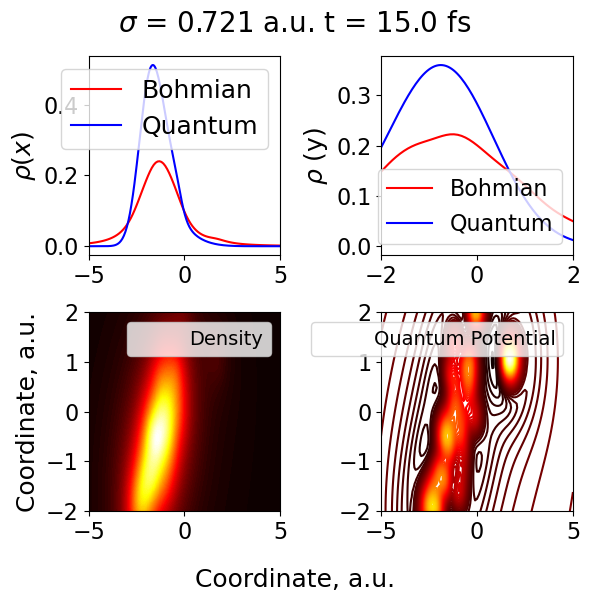

In [203]:
p = torch.load("results/bohmian-mv_cauchy-MartensII-case1-ntraj50-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("MartensII-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-MartensII-case1-ntraj50-dt1.0.pt", 
                      sigma, 600,
                      -5.0, 5.0, 101, 
                      -2.0, 2.0, 51)

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function Martens_model2 at 0x7a8e76660280>, 'ham_params': {'Va': 0.00625, 'Vb': 0.0106, 'Vc': 0.4}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(0.7214233887425682), 'prefix': 'results/bohmian-mv_cauchy-MartensII-case1-ntraj50-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.6015, dtype=torch.float64, grad_fn=<MulBackward0>)


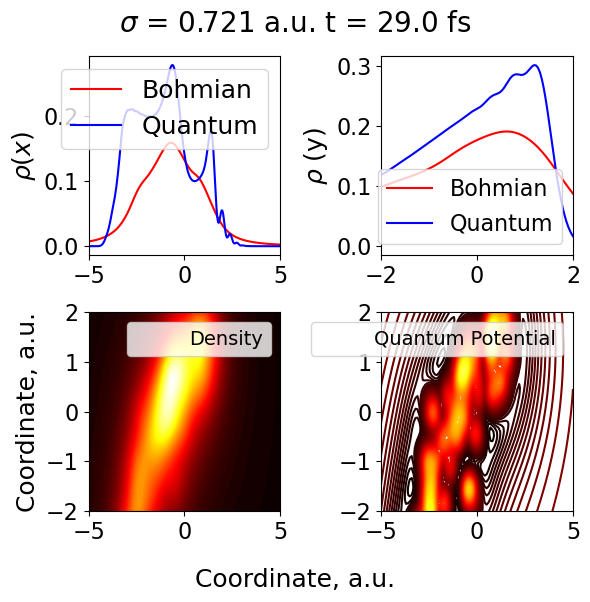

In [202]:
p = torch.load("results/bohmian-mv_cauchy-MartensII-case1-ntraj50-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("MartensII-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-MartensII-case1-ntraj50-dt1.0.pt", 
                      sigma, 1200,
                      -5.0, 5.0, 101, 
                      -2.0, 2.0, 51)

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function Martens_model2 at 0x7a8e76660280>, 'ham_params': {'Va': 0.00625, 'Vb': 0.0106, 'Vc': 0.4}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(0.7214233887425682), 'prefix': 'results/bohmian-mv_cauchy-MartensII-case1-ntraj50-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.6051, dtype=torch.float64, grad_fn=<MulBackward0>)


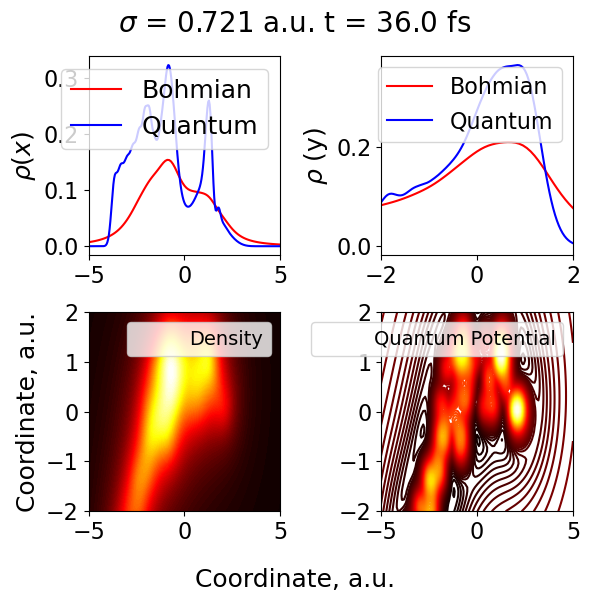

In [201]:
p = torch.load("results/bohmian-mv_cauchy-MartensII-case1-ntraj50-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("MartensII-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-MartensII-case1-ntraj50-dt1.0.pt", 
                      sigma, 1500,
                      -5.0, 5.0, 101, 
                      -2.0, 2.0, 51)

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function Martens_model2 at 0x7a8e76660280>, 'ham_params': {'Va': 0.00625, 'Vb': 0.0106, 'Vc': 0.4}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(0.7214233887425682), 'prefix': 'results/bohmian-mv_cauchy-MartensII-case1-ntraj50-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.4861, dtype=torch.float64, grad_fn=<MulBackward0>)


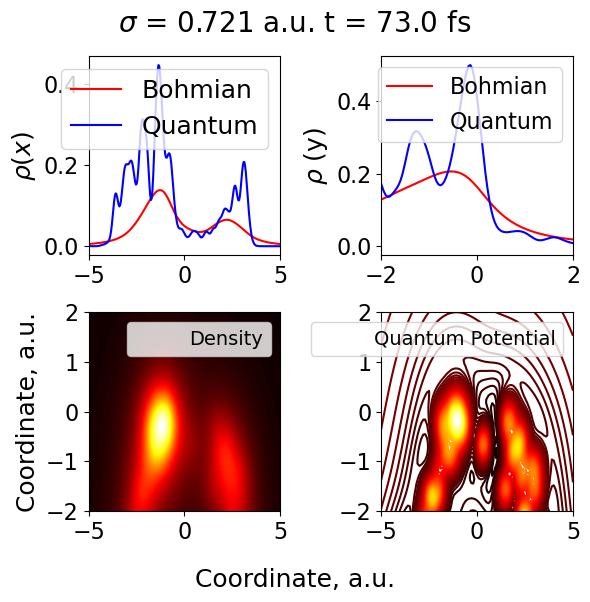

In [200]:
p = torch.load("results/bohmian-mv_cauchy-MartensII-case1-ntraj50-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("MartensII-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-MartensII-case1-ntraj50-dt1.0.pt", 
                      sigma, 3000,
                      -5.0, 5.0, 101, 
                      -2.0, 2.0, 51)

[600, 1200, 1500, 3000]

### N = 1000

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function Martens_model2 at 0x7a8e76660280>, 'ham_params': {'Va': 0.00625, 'Vb': 0.0106, 'Vc': 0.4}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(2.3097955738350695), 'prefix': 'results/bohmian-mv_cauchy-MartensII-case1-ntraj1000-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.3484, dtype=torch.float64, grad_fn=<MulBackward0>)


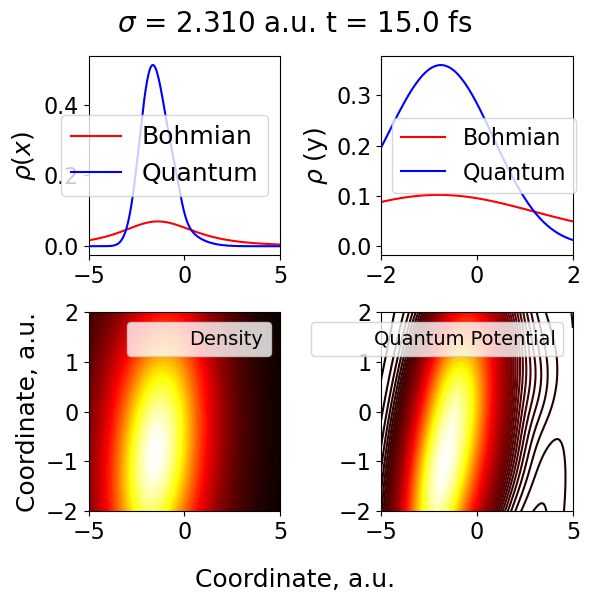

In [204]:
p = torch.load("results/bohmian-mv_cauchy-MartensII-case1-ntraj1000-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("MartensII-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-MartensII-case1-ntraj1000-dt1.0.pt", 
                      sigma, 600,
                      -5.0, 5.0, 101, 
                      -2.0, 2.0, 51)

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function Martens_model2 at 0x7a8e76660280>, 'ham_params': {'Va': 0.00625, 'Vb': 0.0106, 'Vc': 0.4}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(2.3097955738350695), 'prefix': 'results/bohmian-mv_cauchy-MartensII-case1-ntraj1000-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.3272, dtype=torch.float64, grad_fn=<MulBackward0>)


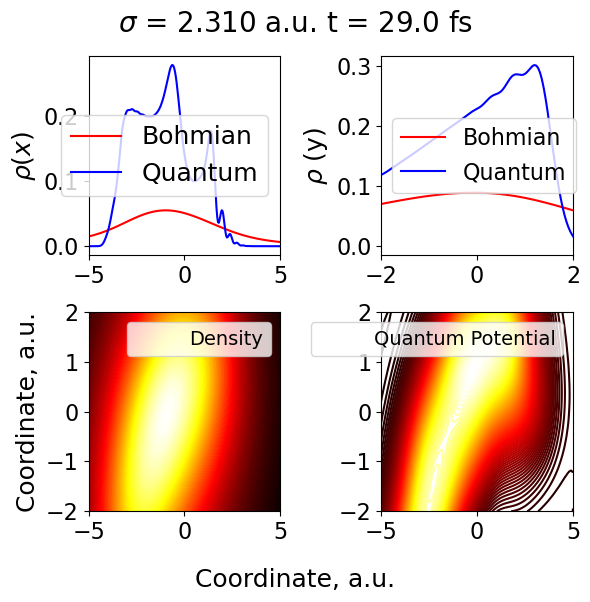

In [205]:
p = torch.load("results/bohmian-mv_cauchy-MartensII-case1-ntraj1000-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("MartensII-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-MartensII-case1-ntraj1000-dt1.0.pt", 
                      sigma, 1200,
                      -5.0, 5.0, 101, 
                      -2.0, 2.0, 51)

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function Martens_model2 at 0x7a8e76660280>, 'ham_params': {'Va': 0.00625, 'Vb': 0.0106, 'Vc': 0.4}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(2.3097955738350695), 'prefix': 'results/bohmian-mv_cauchy-MartensII-case1-ntraj1000-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.3226, dtype=torch.float64, grad_fn=<MulBackward0>)


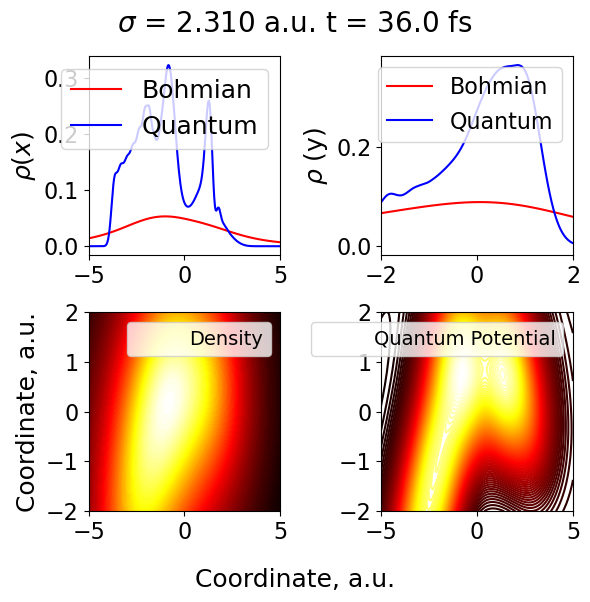

In [206]:
p = torch.load("results/bohmian-mv_cauchy-MartensII-case1-ntraj1000-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("MartensII-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-MartensII-case1-ntraj1000-dt1.0.pt", 
                      sigma, 1500,
                      -5.0, 5.0, 101, 
                      -2.0, 2.0, 51)

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function Martens_model2 at 0x7a8e76660280>, 'ham_params': {'Va': 0.00625, 'Vb': 0.0106, 'Vc': 0.4}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(2.3097955738350695), 'prefix': 'results/bohmian-mv_cauchy-MartensII-case1-ntraj1000-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.2664, dtype=torch.float64, grad_fn=<MulBackward0>)


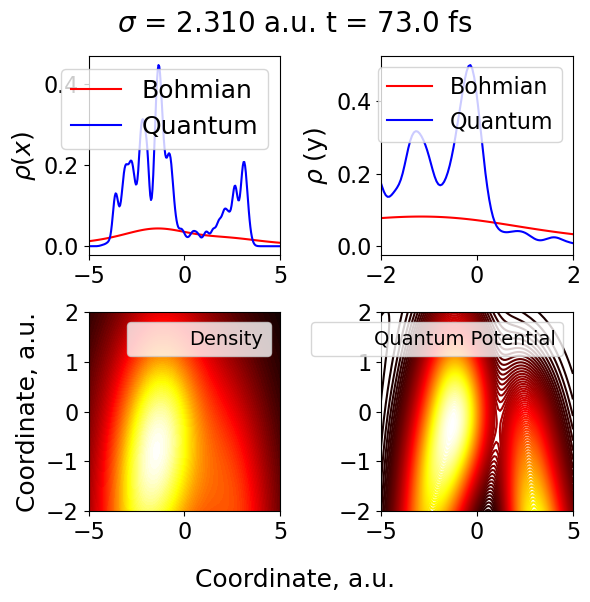

In [207]:
p = torch.load("results/bohmian-mv_cauchy-MartensII-case1-ntraj1000-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("MartensII-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-MartensII-case1-ntraj1000-dt1.0.pt", 
                      sigma, 3000,
                      -5.0, 5.0, 101, 
                      -2.0, 2.0, 51)

## Model III

[600, 1200, 1500, 3000]

### N = 50

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function double_well_2D at 0x7a8e76660d30>, 'ham_params': {'a': 0.005, 'b': 0.015, 'c': 0.005}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(0.3527379270537896), 'prefix': 'results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj50-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.8029, dtype=torch.float64, grad_fn=<MulBackward0>)


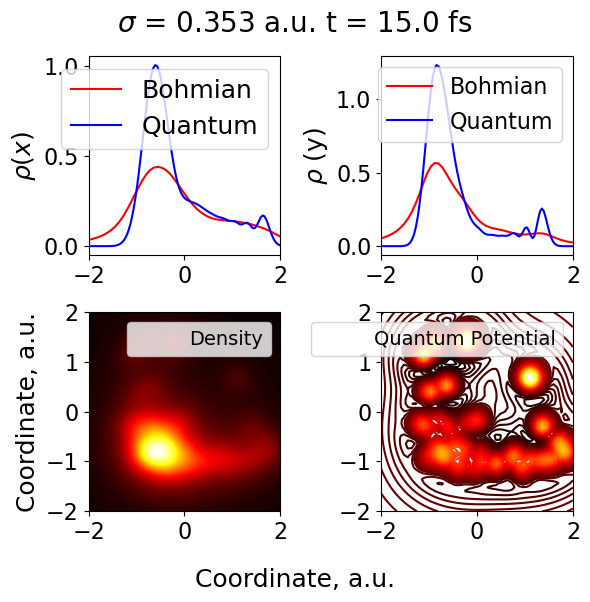

In [212]:
p = torch.load("results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj50-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("Double_well_2D-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj50-dt1.0.pt", 
                      sigma, 600,
                      -2.0, 2.0, 51, 
                      -2.0, 2.0, 51)

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function double_well_2D at 0x7a8e76660d30>, 'ham_params': {'a': 0.005, 'b': 0.015, 'c': 0.005}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(0.3527379270537896), 'prefix': 'results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj50-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.8075, dtype=torch.float64, grad_fn=<MulBackward0>)


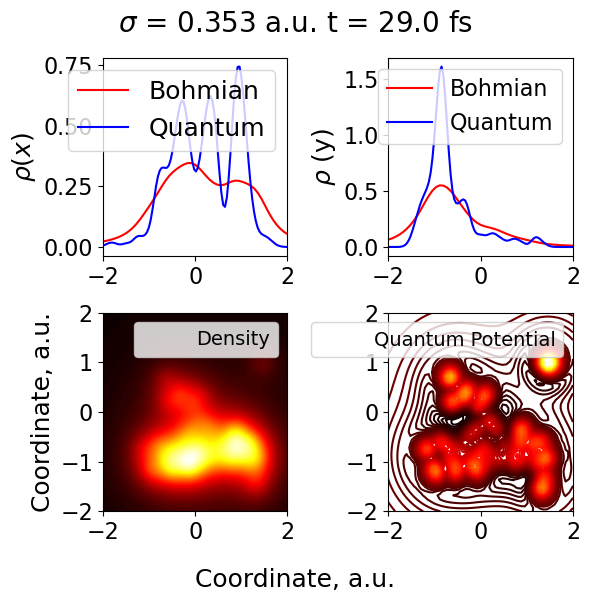

In [213]:
p = torch.load("results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj50-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("Double_well_2D-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj50-dt1.0.pt", 
                      sigma, 1200,
                      -2.0, 2.0, 51, 
                      -2.0, 2.0, 51)

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function double_well_2D at 0x7a8e76660d30>, 'ham_params': {'a': 0.005, 'b': 0.015, 'c': 0.005}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(0.3527379270537896), 'prefix': 'results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj50-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.8081, dtype=torch.float64, grad_fn=<MulBackward0>)


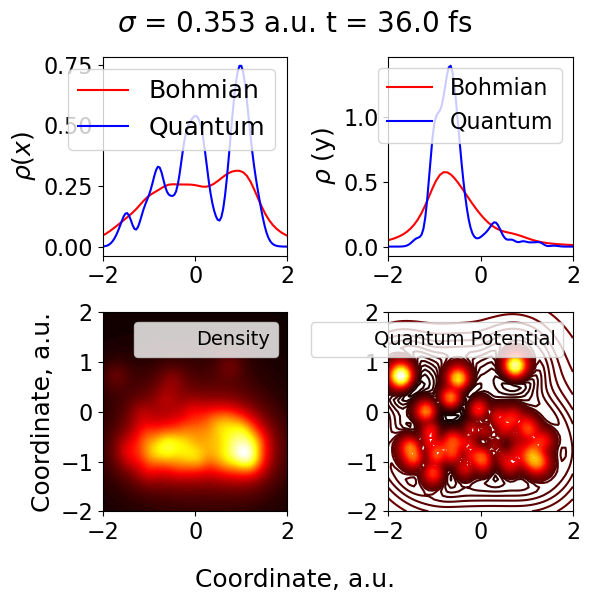

In [214]:
p = torch.load("results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj50-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("Double_well_2D-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj50-dt1.0.pt", 
                      sigma, 1500,
                      -2.0, 2.0, 51, 
                      -2.0, 2.0, 51)

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function double_well_2D at 0x7a8e76660d30>, 'ham_params': {'a': 0.005, 'b': 0.015, 'c': 0.005}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(0.3527379270537896), 'prefix': 'results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj50-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.7999, dtype=torch.float64, grad_fn=<MulBackward0>)


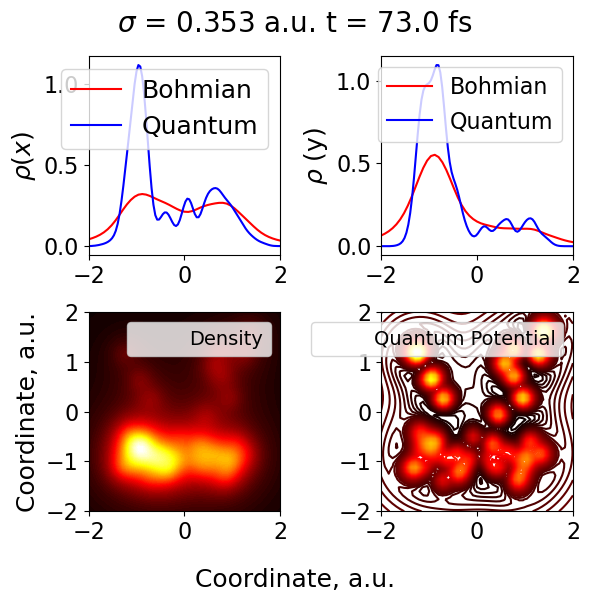

In [215]:
p = torch.load("results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj50-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("Double_well_2D-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj50-dt1.0.pt", 
                      sigma, 3000,
                      -2.0, 2.0, 51, 
                      -2.0, 2.0, 51)

### N = 1000

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function double_well_2D at 0x7a8e76660d30>, 'ham_params': {'a': 0.005, 'b': 0.015, 'c': 0.005}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(1.395980866191595), 'prefix': 'results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj1000-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.4189, dtype=torch.float64, grad_fn=<MulBackward0>)


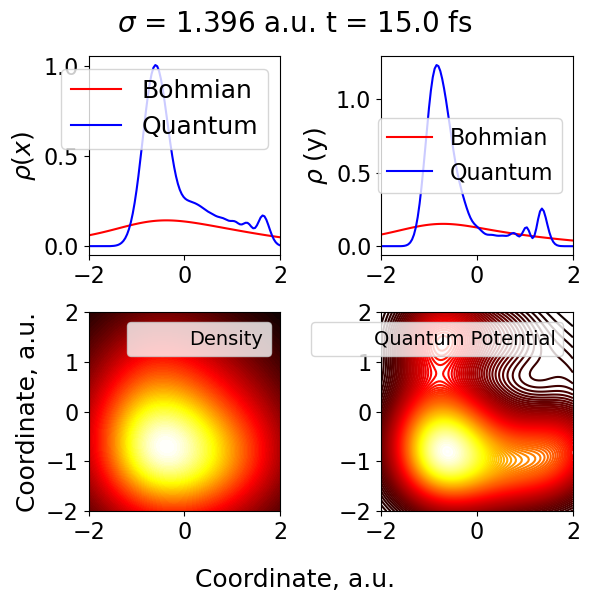

In [216]:
p = torch.load("results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj1000-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("Double_well_2D-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj1000-dt1.0.pt", 
                      sigma, 600,
                      -2.0, 2.0, 101, 
                      -2.0, 2.0, 101)

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function double_well_2D at 0x7a8e76660d30>, 'ham_params': {'a': 0.005, 'b': 0.015, 'c': 0.005}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(1.395980866191595), 'prefix': 'results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj1000-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.4192, dtype=torch.float64, grad_fn=<MulBackward0>)


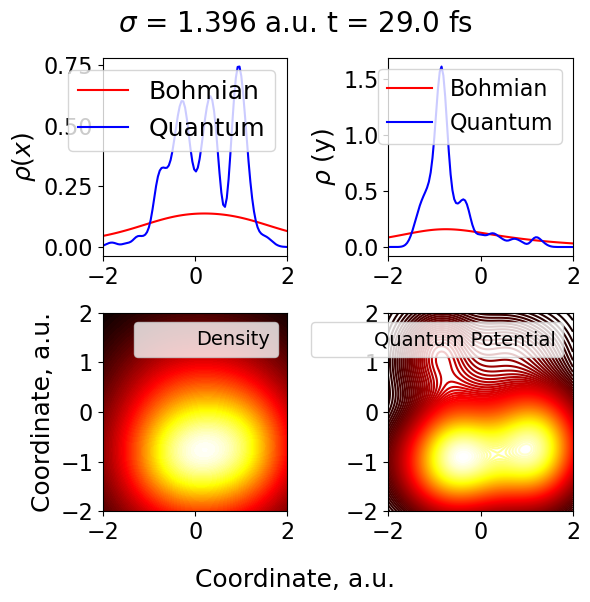

In [217]:
p = torch.load("results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj1000-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("Double_well_2D-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj1000-dt1.0.pt", 
                      sigma, 1200,
                      -2.0, 2.0, 101, 
                      -2.0, 2.0, 101)

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function double_well_2D at 0x7a8e76660d30>, 'ham_params': {'a': 0.005, 'b': 0.015, 'c': 0.005}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(1.395980866191595), 'prefix': 'results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj1000-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.4166, dtype=torch.float64, grad_fn=<MulBackward0>)


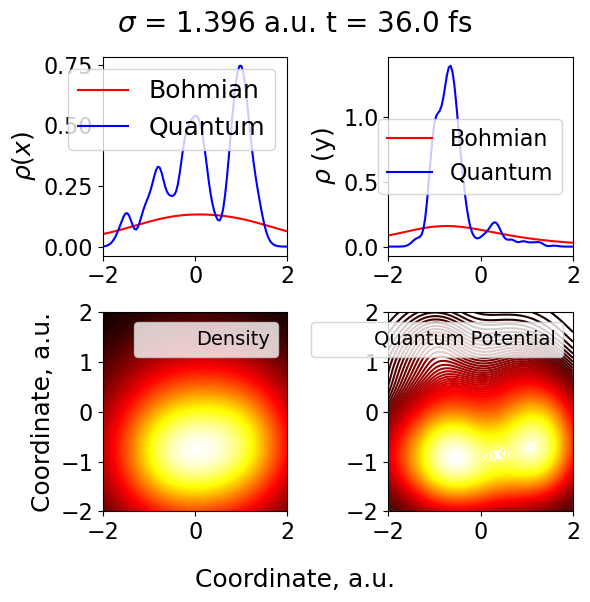

In [218]:
p = torch.load("results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj1000-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("Double_well_2D-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj1000-dt1.0.pt", 
                      sigma, 1500,
                      -2.0, 2.0, 101, 
                      -2.0, 2.0, 101)

{'nsteps': 4000, 'dt': 1.0, 'print_period': 8, 'ham': <function double_well_2D at 0x7a8e76660d30>, 'ham_params': {'a': 0.005, 'b': 0.015, 'c': 0.005}, 'do_bohmian': 1, 'tbf_type': <function rho_mv_cauchy at 0x7a8e76624820>, 'qpot_sigmas': np.float64(1.395980866191595), 'prefix': 'results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj1000-dt1.0'}


/tmp/ipykernel_3047/871917395.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_x = rho.sum(axis=1) * dy.detach().numpy()
/tmp/ipykernel_3047/871917395.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rho_y = rho.sum(axis=0) * dx.detach().numpy()


Total norm Bohmian =  tensor(0.4138, dtype=torch.float64, grad_fn=<MulBackward0>)


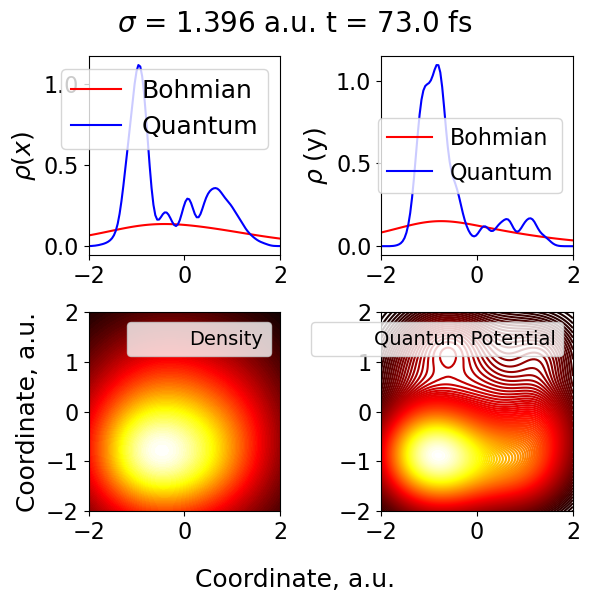

In [219]:
p = torch.load("results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj1000-dt1.0-params.pt", weights_only=False)
print(p)
sigma = p["qpot_sigmas"]
x,y = plot_rho_quant_pot_2D("Double_well_2D-case1-exact.pt", 
                      "results/bohmian-mv_cauchy-Double_well_2D-case1-ntraj1000-dt1.0.pt", 
                      sigma, 3000,
                      -2.0, 2.0, 101, 
                      -2.0, 2.0, 101)

## Below are my attempts to optimize the plotting functions 

In [3]:
def rho_mv_cauchy(q, Q, sigma):
    """
    q: (..., ndof)  # evaluation points (can be many)
    Q: (ntraj, ndof)  # trajectory centers
    sigma: float or tensor
    """
    ntraj, ndof = Q.shape[-2], Q.shape[-1]

    num = torch.lgamma(torch.tensor(0.5 * (ndof + 1), dtype=torch.float64))
    denom = (
        torch.lgamma(torch.tensor(0.5, dtype=torch.float64)) +
        0.5 * ndof * math.log(math.pi) +
        ndof * math.log(float(sigma))
    )
    norm = torch.exp(num - denom)

    # broadcasting: (N, 1, ndof) - (1, ntraj, ndof) -> (N, ntraj, ndof)
    diff = q.unsqueeze(1) - Q.unsqueeze(0)
    r2 = (diff**2).sum(dim=-1)  # (N, ntraj)

    LZ = (1.0 + r2 / sigma**2) ** (-(ndof + 1) / 2)  # (N, ntraj)

    f = (1.0 / ntraj) * norm * LZ.sum(dim=1)  # (N,)
    return f

In [4]:
def quantum_potential_original_gen(q, Q, sigma, mass, TBF):
    """
    Args:
    * q (Tensor(N, ndof)) or (ndof,) - evaluation points
    * Q (Tensor(ntraj, ndof)) - trajectory centers
    * sigma (float or Tensor) - width
    * mass (Tensor(ndof)) - masses
    * TBF (callable) - density basis function (e.g. rho_mv_cauchy)

    Returns:
    Tensor(N,) - quantum potential at each evaluation point
    """

    # ensure q has batch dimension
    if q.ndim == 1:
        q = q.unsqueeze(0)  # (1, ndof)

    N, ndof = q.shape

    # make q require gradients
    q = q.clone().detach().requires_grad_(True)

    # f: (N,)  density evaluated at each point
    f = TBF(q, Q, sigma)

    # grad wrt q: shape (N, ndof)
    deriv1 = torch.autograd.grad(
        f, q,
        grad_outputs=torch.ones_like(f),
        create_graph=True,
        retain_graph=True
    )[0]

    U = torch.zeros(N, dtype=f.dtype, device=f.device)

    for i in range(ndof):
        # second derivative of f wrt q[:, i]
        deriv2 = torch.autograd.grad(
            deriv1[:, i], q,
            grad_outputs=torch.ones_like(deriv1[:, i]),
            create_graph=True,
            retain_graph=True
        )[0][:, i]  # pick only the i-th component

        u_i = -(0.25 / mass[i]) * (deriv2 / f - 0.5 * (deriv1[:, i] / f) ** 2)
        U = U + u_i

    return U  # (N,)


In [5]:
def plot_rho(filename_quantum, filename, _sigma, timestep, npts=201):
    """
    # _sigma 
    # The standard deviation of the initial wavepacket 
    mass = 2000.0
    omega = 0.004
    sigma_q = np.sqrt(0.5/(mass*omega))
    print(sigma_q)
    # Use the Scott's rule for kernel bandwidth
    d = 2
    _sigma = sigma_q * _ntraj**(-1.0/(d+4)) # Scott's rule
    
    print(_sigma)
    """
    
    sigma = torch.tensor( [_sigma] )
    mass = torch.tensor( [2000.0, 2000.0] )

    qq = torch.load(filename_quantum, weights_only=False)    
    f = torch.load(filename, weights_only=False)    
    Q = f["q_traj"][timestep, :, :]
    
    x = torch.linspace(-20.0, 20.0, npts, requires_grad=True)
    y = torch.linspace(-15.0, 15.0, npts, requires_grad=True)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    X, Y = torch.meshgrid(x, y, indexing='ij')  # 'ij' indexing matches matrix notation    
    coords = torch.stack([X, Y], dim=-1) 
   
    rho, U = [], []
    # Then each entry coords[i, j] is a 2D vector [x, y]
        
    nx, ny = coords.shape[0], coords.shape[1]
    
    """
    for _x in coords.reshape(-1, 2):
        ntraj, ndof = Q.shape[-2], Q.shape[-1]
        #f = rho_lorentzian(_x, Q, sigma)
        f = compute.rho_mv_cauchy(_x, Q, sigma)
        #u = compute.quantum_potential_original_gen(_x, Q, sigma, mass, compute.rho_mv_cauchy) 
        rho.append(f.detach())
        U.append(torch.tensor(0.0))
    rho = torch.tensor(rho)
    rho = rho.reshape(nx, ny)
    """
    coords2d = coords.reshape(-1, 2)            # (nx*ny, 2)
    rho = rho_mv_cauchy(coords2d, Q, sigma)  # should return (nx*ny,) or (nx*ny, ...)

    #rho = compute.rho_lorentzian(coords.reshape(-1,2), Q, sigma)
    rho = rho.reshape(nx, ny)
    
    #U = torch.tensor(U)
    
    U = quantum_potential_original_gen(coords2d, Q, sigma, mass, rho_mv_cauchy) 
    U = U.reshape(nx, ny)
    U = U.detach().cpu().numpy()
    #U = torch.zeros_like(rho)#.detach().numpy()
    #rho = rho.detach().numpy()
            
    #rho = rho/norm
    #norm = (rho.sum() * dx * dy).detach().item()
    #rho = rho / norm
    rho_x = rho.sum(axis=1).detach().cpu().numpy()
    rho_y = rho.sum(axis=0).detach().cpu().numpy()
    rho = rho.detach().cpu().numpy()

    print("Total norm Bohmian = ", rho.sum() * dx * dy)

    n = qq["save_every_n_steps"]
    dt = qq["dt"]
    dq = qq["dq"]
    qQ = qq["Q"]
    #V = qq["V"]
    t = timestep * dt /units.fs2au
    psi = qq["psi_all"][int(timestep/n)]
    qrho = (torch.abs( psi ) )**2 
    qrho_x = qrho.sum(axis=1) #* dq[1]
    qrho_y = qrho.sum(axis=0) #* dq[0]
    
    # Grid of quantum calculuations
    qx = torch.linspace(qq["q_min"][0], qq["q_max"][0], qq["grid_size"][0])
    qy = torch.linspace(qq["q_min"][1], qq["q_max"][1], qq["grid_size"][1])
    
    sz = 16
    # Create 1 row, 2 columns of subplots
    fig, axs = plt.subplots(2, 2, figsize=(6, 6)) # sharex=True, sharey=True)
    
    axs[0,0].plot(x.detach(), rho_x, color="red", label="Bohmian") 
    axs[0,0].plot(qx, qrho_x, color="blue", label="Quantum") 
    axs[0,0].set_ylabel(r"$\rho (x)$", fontsize=18)
    axs[0,0].legend(fontsize=18)
    axs[0,0].tick_params(axis='x', labelsize=sz)
    axs[0,0].tick_params(axis='y', labelsize=sz) 
    axs[0,0].set_xlim(-20, 20)  
    
    axs[0,1].plot(y.detach(), rho_y, color="red", label="Bohmian") 
    axs[0,1].plot(qy, qrho_y, color="blue", label="Quantum") 
    axs[0,1].set_ylabel(r"$\rho$ (y)", fontsize=18)
    axs[0,1].legend(fontsize=16)
    axs[0,1].tick_params(axis='x', labelsize=sz)
    axs[0,1].tick_params(axis='y', labelsize=sz) 
    axs[0,1].set_xlim(-15, 15)

    X = X.detach()
    Y = Y.detach()
    axs[1,0].contourf(X, Y, rho, levels=100, cmap="hot")
    axs[1,0].plot([], [], color="none", label="Density")
    axs[1,0].legend(fontsize=14)
    axs[1,0].set_ylabel('Coordinate, a.u.', fontsize=18)
    axs[1,0].tick_params(axis='x', labelsize=sz)
    axs[1,0].tick_params(axis='y', labelsize=sz) 
    axs[1,0].set_xlim(-5, 5)
    axs[1,0].set_ylim(-5, 5)

    axs[1,1].contour(X, Y, U, levels=100, cmap='hot')
    axs[1,1].plot([], [], color="none", label="Quantum Potential")
    axs[1,1].legend(fontsize=14)
    axs[1,1].tick_params(axis='x', labelsize=sz)
    axs[1,1].tick_params(axis='y', labelsize=sz) 
    axs[1,1].set_xlim(-5, 5)
    axs[1,1].set_ylim(-5, 5)
    
    # Centered shared x-axis label
    title = F"$\sigma$ = {_sigma:.3f} a.u. t = { round(t,0) } fs"
    fig.suptitle(title, fontsize=20)
    fig.supxlabel('Coordinate, a.u.', fontsize=18)
    #fig.supylabel('Coordinate, a.u.', fontsize=18)
    plt.tight_layout()
    plt.show()